假设我们不以全年为测试集,这样我们尽可能利用最近的时间作为验证集,选一个好的种子.将每个月的折线连起来.是否能进行改进?

# 2020逐月回测：前三个月验证选种子，堆叠各100轮

沿用11最后的两阶段Stacking：第一阶段原7变量→股价；第二阶段第一阶段预测＋金铜昨日涨幅、相对5/20期均价涨幅→股价。两阶段均16→32隐藏层、ReLU、Adam学习率0.01、全批量、各100轮；样本内堆叠，不用折外预测。

候选种子随机抽取10个、排除旧实验种子，并在训练前冻结；全年每月使用相同候选，便于比較。下面代码直接保存具体种子，重新运行不会再次抽样。

每个预测月M：训练数据为验证期开始以前的全部历史；验证期为M前连续3个日历月；测试为M当月。例如2020年1月：训练截至2019-09-30，验证2019-10-01至2019-12-31，测试2020-01-01至2020-01-31。2月训练截至2019-10-31，验证2019年11月至2020年1月，测试2月，依次滚动。此前已发生的月份可以进入后续验证/训练，但未来月份不能进入。

只按验证MAPE最低选择种子，精确并列按固定候选顺序。锁定后不加入验证集重训。选择记录先落盘，再评估当月测试。拼接12个月后报告逐记录全年MAPE（等价于按样本数加权的月MAPE）和12个月等权平均MAPE。

对照：把1月验证选中的同一模型全年冻结，在相同2020日期评估，比较逐月更新是否改善。此对照与1月滚动结果必须一致。两种方案同起点、同候选，比较的变化包括每月扩大训练数据与更新验证/选择，并非单独检验某一个因素。

**时间可用性限制**：输入包含同日金铜价格等，因此是逐月更新模型的同日股价样本外回测，不能称为月初已知整个未来月的预测。此前已查看过2020年，属于历史开发实验，不是全新盲测。滚动均价包括当天、窗口按记录计数，未重新修改原Dataset对齐方式。


In [1]:
from pathlib import Path
import os,json,hashlib,random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display,Image
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP12_OUT',str(ROOT/'results/mlp_monthly_validation_12')));OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]
EXCLUDED_SEEDS=[0, 1, 7, 21, 42, 100, 123, 999, 2024, 2025]
EPOCHS=100;LR=0.01;VALIDATION_MONTHS=3
torch.set_num_threads(1);torch.use_deterministic_algorithms(True)
assert len(set(SEEDS))==10 and not set(SEEDS)&set(EXCLUDED_SEEDS)
dataset=ROOT/'src/pickle/Dataset.pkl';d=pd.read_pickle(dataset)
raw=d['X'].copy();target=d['Y'].copy();assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
raw=raw.loc[raw.index<'2021-01-01'];BASE=list(raw.columns);assert len(BASE)==7
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy();RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily';x[name]=raw[col]/raw[col].shift(1)-1;RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}';x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1;RETURNS.append(name)
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
x=x.loc[valid];y=y.loc[x.index];assert (y>0).all()
whole=x.index[x.index.year==2020];assert len(whole)==271
config=dict(seeds=SEEDS,excluded_prior_seeds=EXCLUDED_SEEDS,epochs_per_stage=EPOCHS,validation_months=VALIDATION_MONTHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions; base frozen',refit_after_selection=False,target='same-date original price',selection='minimum preceding-three-calendar-month MAPE; ties by candidate order',test_year=2020,dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
print('Frozen candidate seeds:',SEEDS)


Frozen candidate seeds: [965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]


In [2]:
history=[]
def fit_stage(X,train_idx,seed,stage,month):
    random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
    sx=StandardScaler().fit(X.loc[train_idx]);sy=StandardScaler().fit(y.loc[train_idx].to_numpy().reshape(-1,1))
    xt=torch.tensor(sx.transform(X.loc[train_idx]),dtype=torch.float32);yt=torch.tensor(sy.transform(y.loc[train_idx].to_numpy().reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    for epoch in range(1,EPOCHS+1):
        model.train();opt.zero_grad();loss=((model(xt)-yt)**2).mean();assert torch.isfinite(loss)
        loss.backward();opt.step();model.eval()
        with torch.no_grad():z=model(xt).numpy()
        p=sy.inverse_transform(z).ravel();mse=float(np.mean((p-y.loc[train_idx].to_numpy())**2))
        history.append(dict(Month=month,Seed=seed,Stage=stage,Epoch=epoch,Train_MSE=mse,Train_MSE_standardized=mse/float(sy.scale_[0]**2)))
    torch.save(dict(state_dict=model.state_dict(),features=list(X.columns),seed=seed,epochs=EPOCHS,train_start=str(train_idx.min()),train_end=str(train_idx.max()),sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist()),OUT/f'{month}_{stage}_seed{seed}.pt')
    return model,sx,sy

def predict(bundle,X):
    model,sx,sy=bundle;model.eval()
    with torch.no_grad():z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    p=sy.inverse_transform(z).ravel();assert np.isfinite(p).all();return pd.Series(p,index=X.index)

def score(pred,idx):
    err=pred.loc[idx].to_numpy()-y.loc[idx].to_numpy()
    return dict(N=len(idx),MAPE=float(100*np.mean(np.abs(err)/np.abs(y.loc[idx].to_numpy()))),MSE=float(np.mean(err**2)))

def stack_predict(base,stack,X):
    bp=predict(base,X[BASE]);meta=X[RETURNS].copy();meta.insert(0,'base_prediction',bp)
    return predict(stack,meta)

splitrows=[];valrows=[];testrows=[];selections=[];testframes=[];valframes=[];trainrows=[];selectedframes=[]
for month_start in pd.date_range('2020-01-01','2020-12-01',freq='MS'):
    month=month_start.strftime('%Y-%m');val_start=month_start-pd.DateOffset(months=VALIDATION_MONTHS);month_end=month_start+pd.DateOffset(months=1)
    tr=x.index[x.index<val_start];va=x.index[(x.index>=val_start)&(x.index<month_start)];te=x.index[(x.index>=month_start)&(x.index<month_end)]
    assert len(tr)>0 and len(va)>0 and len(te)>0 and tr.max()<va.min() and va.max()<te.min()
    for split,idx in [('Train',tr),('Validation',va),('Test',te)]:
        splitrows.append(dict(Month=month,Split=split,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())))
    # Candidate fitting and ranking do not access target-month labels.
    known=x.loc[x.index<month_start];bundles={};monthvals=[]
    for i,seed in enumerate(SEEDS):
        base=fit_stage(known[BASE],tr,seed,'Base',month)
        bp=predict(base,known[BASE]);meta=known[RETURNS].copy();meta.insert(0,'base_prediction',bp)
        stack=fit_stage(meta,tr,seed,'Stacking',month);bundles[seed]=(base,stack)
        vp=predict(stack,meta)
        monthvals.append(dict(Month=month,Seed=seed,Candidate_order=i,**score(vp,va)))
        trainrows.append(dict(Month=month,Seed=seed,**score(vp,tr)))
        valframes.append(pd.DataFrame(dict(Date=va,Month=month,Seed=seed,Actual=y.loc[va].to_numpy(),Predicted=vp.loc[va].to_numpy())))
    ranking=pd.DataFrame(monthvals).sort_values(['MAPE','Candidate_order']).reset_index(drop=True)
    ranking['Rank']=np.arange(1,len(ranking)+1);chosen=int(ranking.iloc[0].Seed);ranking['Selected']=ranking.Seed.eq(chosen)
    valrows.extend(ranking.to_dict('records'))
    decision=dict(Month=month,Selected_seed=chosen,Validation_MAPE=float(ranking.iloc[0].MAPE),Train_end=str(tr.max().date()),Validation_start=str(va.min().date()),Validation_end=str(va.max().date()),Test_start=str(te.min().date()),Test_end=str(te.max().date()),Refit=False)
    # Lock and persist before any target-month evaluation.
    (OUT/f'{month}_selection.json').write_text(json.dumps(decision,ensure_ascii=False,indent=2));selections.append(decision)
    if month=='2020-01':annual_base,annual_stack=bundles[chosen];annual_seed=chosen
    for seed in SEEDS:
        base,stack=bundles[seed];pred=stack_predict(base,stack,x.loc[te]);metrics=score(pred,te)
        testrows.append(dict(Month=month,Seed=seed,Selected=seed==chosen,**metrics))
        frame=pd.DataFrame(dict(Date=te,Month=month,Seed=seed,Actual=y.loc[te].to_numpy(),Predicted=pred.to_numpy()))
        testframes.append(frame)
        if seed==chosen:selectedframes.append(frame)
    print(f'{month}: selected seed {chosen}, validation MAPE {decision["Validation_MAPE"]:.3f}%',flush=True)

validation=pd.DataFrame(valrows);test_metrics=pd.DataFrame(testrows);selection=pd.DataFrame(selections)
stitched=pd.concat(selectedframes,ignore_index=True).sort_values('Date');stitched['APE']=100*np.abs(stitched.Predicted-stitched.Actual)/stitched.Actual.abs()
assert pd.DatetimeIndex(stitched.Date).equals(whole) and stitched.Date.is_unique
assert len(history)==12*10*2*100 and len(validation)==120 and len(test_metrics)==120
for m,g in validation.groupby('Month'):
    assert int(g.sort_values('Rank').iloc[0].Seed)==int(selection.loc[selection.Month==m,'Selected_seed'].iloc[0])
annual_pred=stack_predict(annual_base,annual_stack,x.loc[whole])
stitched['Frozen_annual_prediction']=annual_pred.to_numpy()
stitched['Frozen_annual_APE']=100*np.abs(stitched.Frozen_annual_prediction-stitched.Actual)/stitched.Actual.abs()
jan=stitched.Month=='2020-01';assert np.allclose(stitched.loc[jan,'Predicted'],stitched.loc[jan,'Frozen_annual_prediction'],rtol=0,atol=1e-6)
monthly=selection.merge(test_metrics[test_metrics.Selected][['Month','N','MAPE','MSE']].rename(columns={'MAPE':'Test_MAPE','MSE':'Test_MSE'}),on='Month',validate='one_to_one')
monthly=monthly.merge(stitched.groupby('Month').Frozen_annual_APE.mean().rename('Frozen_annual_MAPE'),on='Month',validate='one_to_one')
monthly['Rolling_minus_frozen_pp']=monthly.Test_MAPE-monthly.Frozen_annual_MAPE
summary=pd.DataFrame([dict(Method='Monthly validation selection',Annual_daily_MAPE=stitched.APE.mean(),Monthly_equal_MAPE=monthly.Test_MAPE.mean(),Annual_MSE=np.mean((stitched.Predicted-stitched.Actual)**2)),dict(Method='January selected model frozen all year',Annual_daily_MAPE=stitched.Frozen_annual_APE.mean(),Monthly_equal_MAPE=monthly.Frozen_annual_MAPE.mean(),Annual_MSE=np.mean((stitched.Frozen_annual_prediction-stitched.Actual)**2))])
assert np.isclose(stitched.APE.mean(),np.average(monthly.Test_MAPE,weights=monthly.N))
for name,frame in [('splits',pd.DataFrame(splitrows)),('validation_ranking',validation),('test_metrics_all_candidates',test_metrics),('train_metrics',pd.DataFrame(trainrows)),('selection',selection),('stitched_predictions',stitched),('monthly_results',monthly),('summary',summary),('training_history',pd.DataFrame(history)),('candidate_test_predictions',pd.concat(testframes,ignore_index=True)),('candidate_validation_predictions',pd.concat(valframes,ignore_index=True))]:frame.to_csv(OUT/f'{name}.csv',index=False)
print('Monthly selection and test results:');display(monthly[['Month','Selected_seed','Validation_MAPE','Test_MAPE','Frozen_annual_MAPE','Rolling_minus_frozen_pp']].round(4))
print('Annual comparison:');display(summary.round(4))


,Month,Selected_seed,Validation_MAPE,Test_MAPE,Frozen_annual_MAPE,Rolling_minus_frozen_pp
0,2020-01,785634,6.0256,12.4420,12.4420,0.0000
1,2020-02,785634,9.2545,14.2954,12.9335,1.3619
2,2020-03,785634,12.5468,5.6804,7.9675,-2.2871
3,2020-04,798291,6.7915,3.7448,3.1950,0.5499
4,2020-05,741131,4.5831,3.6497,5.3179,-1.6682
5,2020-06,741131,4.6159,13.3628,8.4461,4.9167
6,2020-07,965409,2.9153,13.3470,5.6452,7.7018
7,2020-08,798291,3.8530,7.6893,14.3553,-6.6659
8,2020-09,565766,5.6801,14.5983,22.2193,-7.6211
9,2020-10,42716,8.8443,12.4556,20.5544,-8.0989


,Method,Annual_daily_MAPE,Monthly_equal_MAPE,Annual_MSE
0,Monthly validation selection,11.5270,11.5536,0.7955
1,January selected model frozen all year,14.5383,14.6069,1.7473


2020-01: selected seed 785634, validation MAPE 6.026%
2020-02: selected seed 785634, validation MAPE 9.254%
2020-03: selected seed 785634, validation MAPE 12.547%
2020-04: selected seed 798291, validation MAPE 6.791%
2020-05: selected seed 741131, validation MAPE 4.583%
2020-06: selected seed 741131, validation MAPE 4.616%
2020-07: selected seed 965409, validation MAPE 2.915%
2020-08: selected seed 798291, validation MAPE 3.853%
2020-09: selected seed 565766, validation MAPE 5.680%
2020-10: selected seed 42716, validation MAPE 8.844%
2020-11: selected seed 385735, validation MAPE 8.294%
2020-12: selected seed 965409, validation MAPE 10.996%
Monthly selection and test results:
Annual comparison:


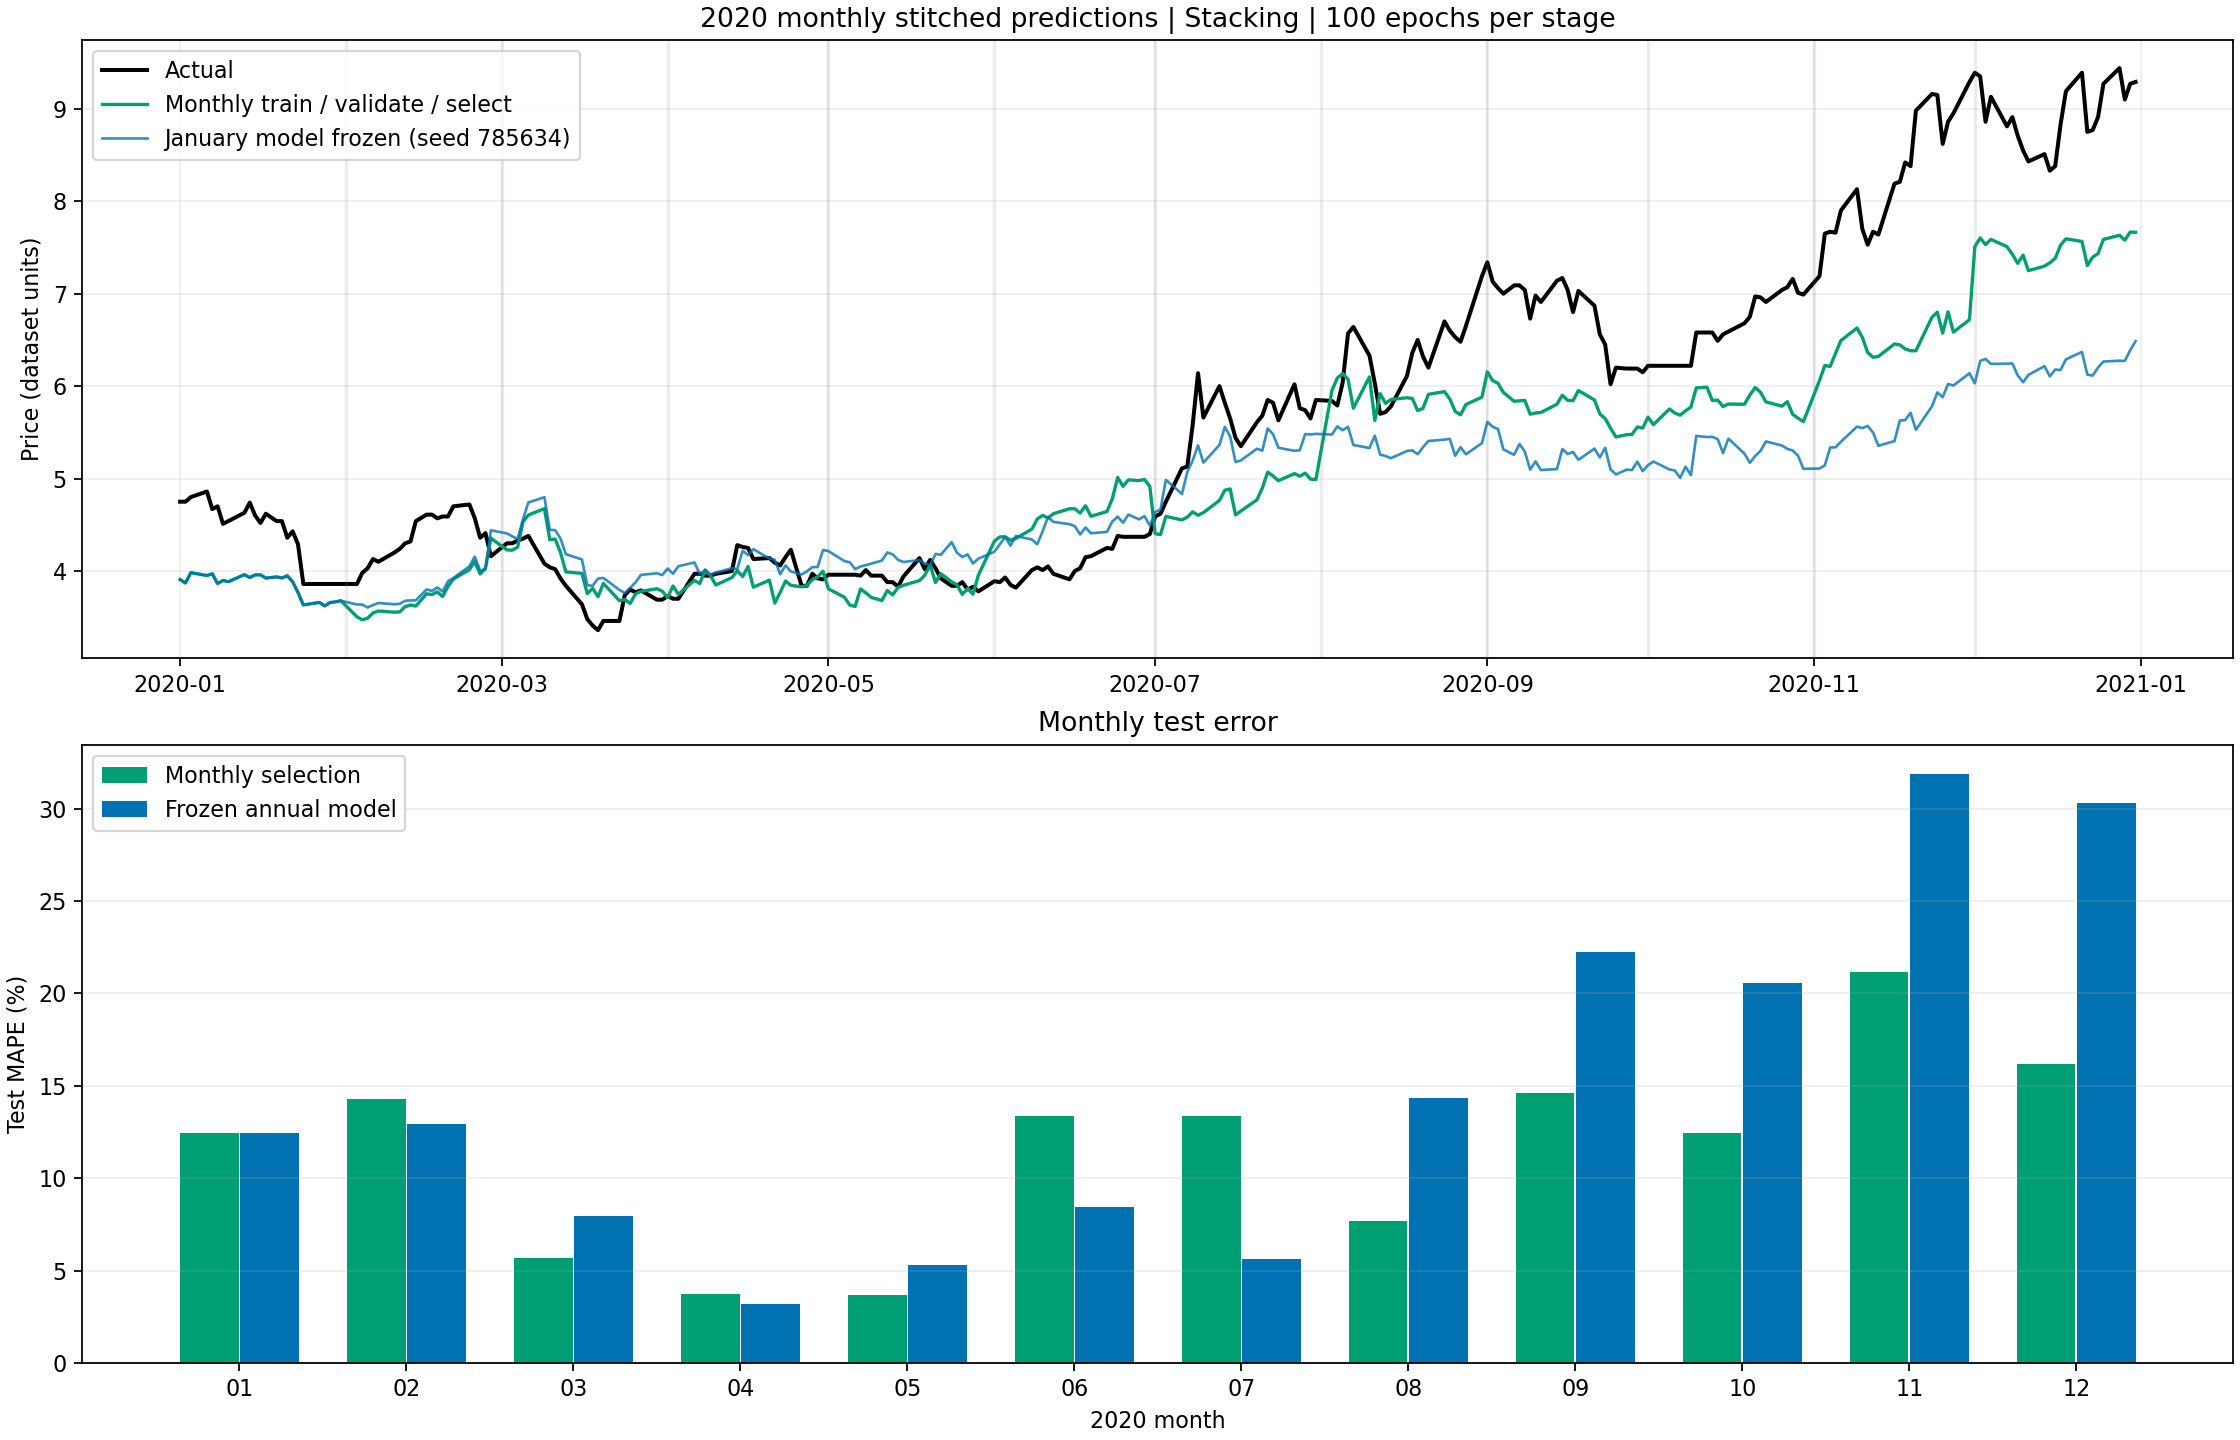

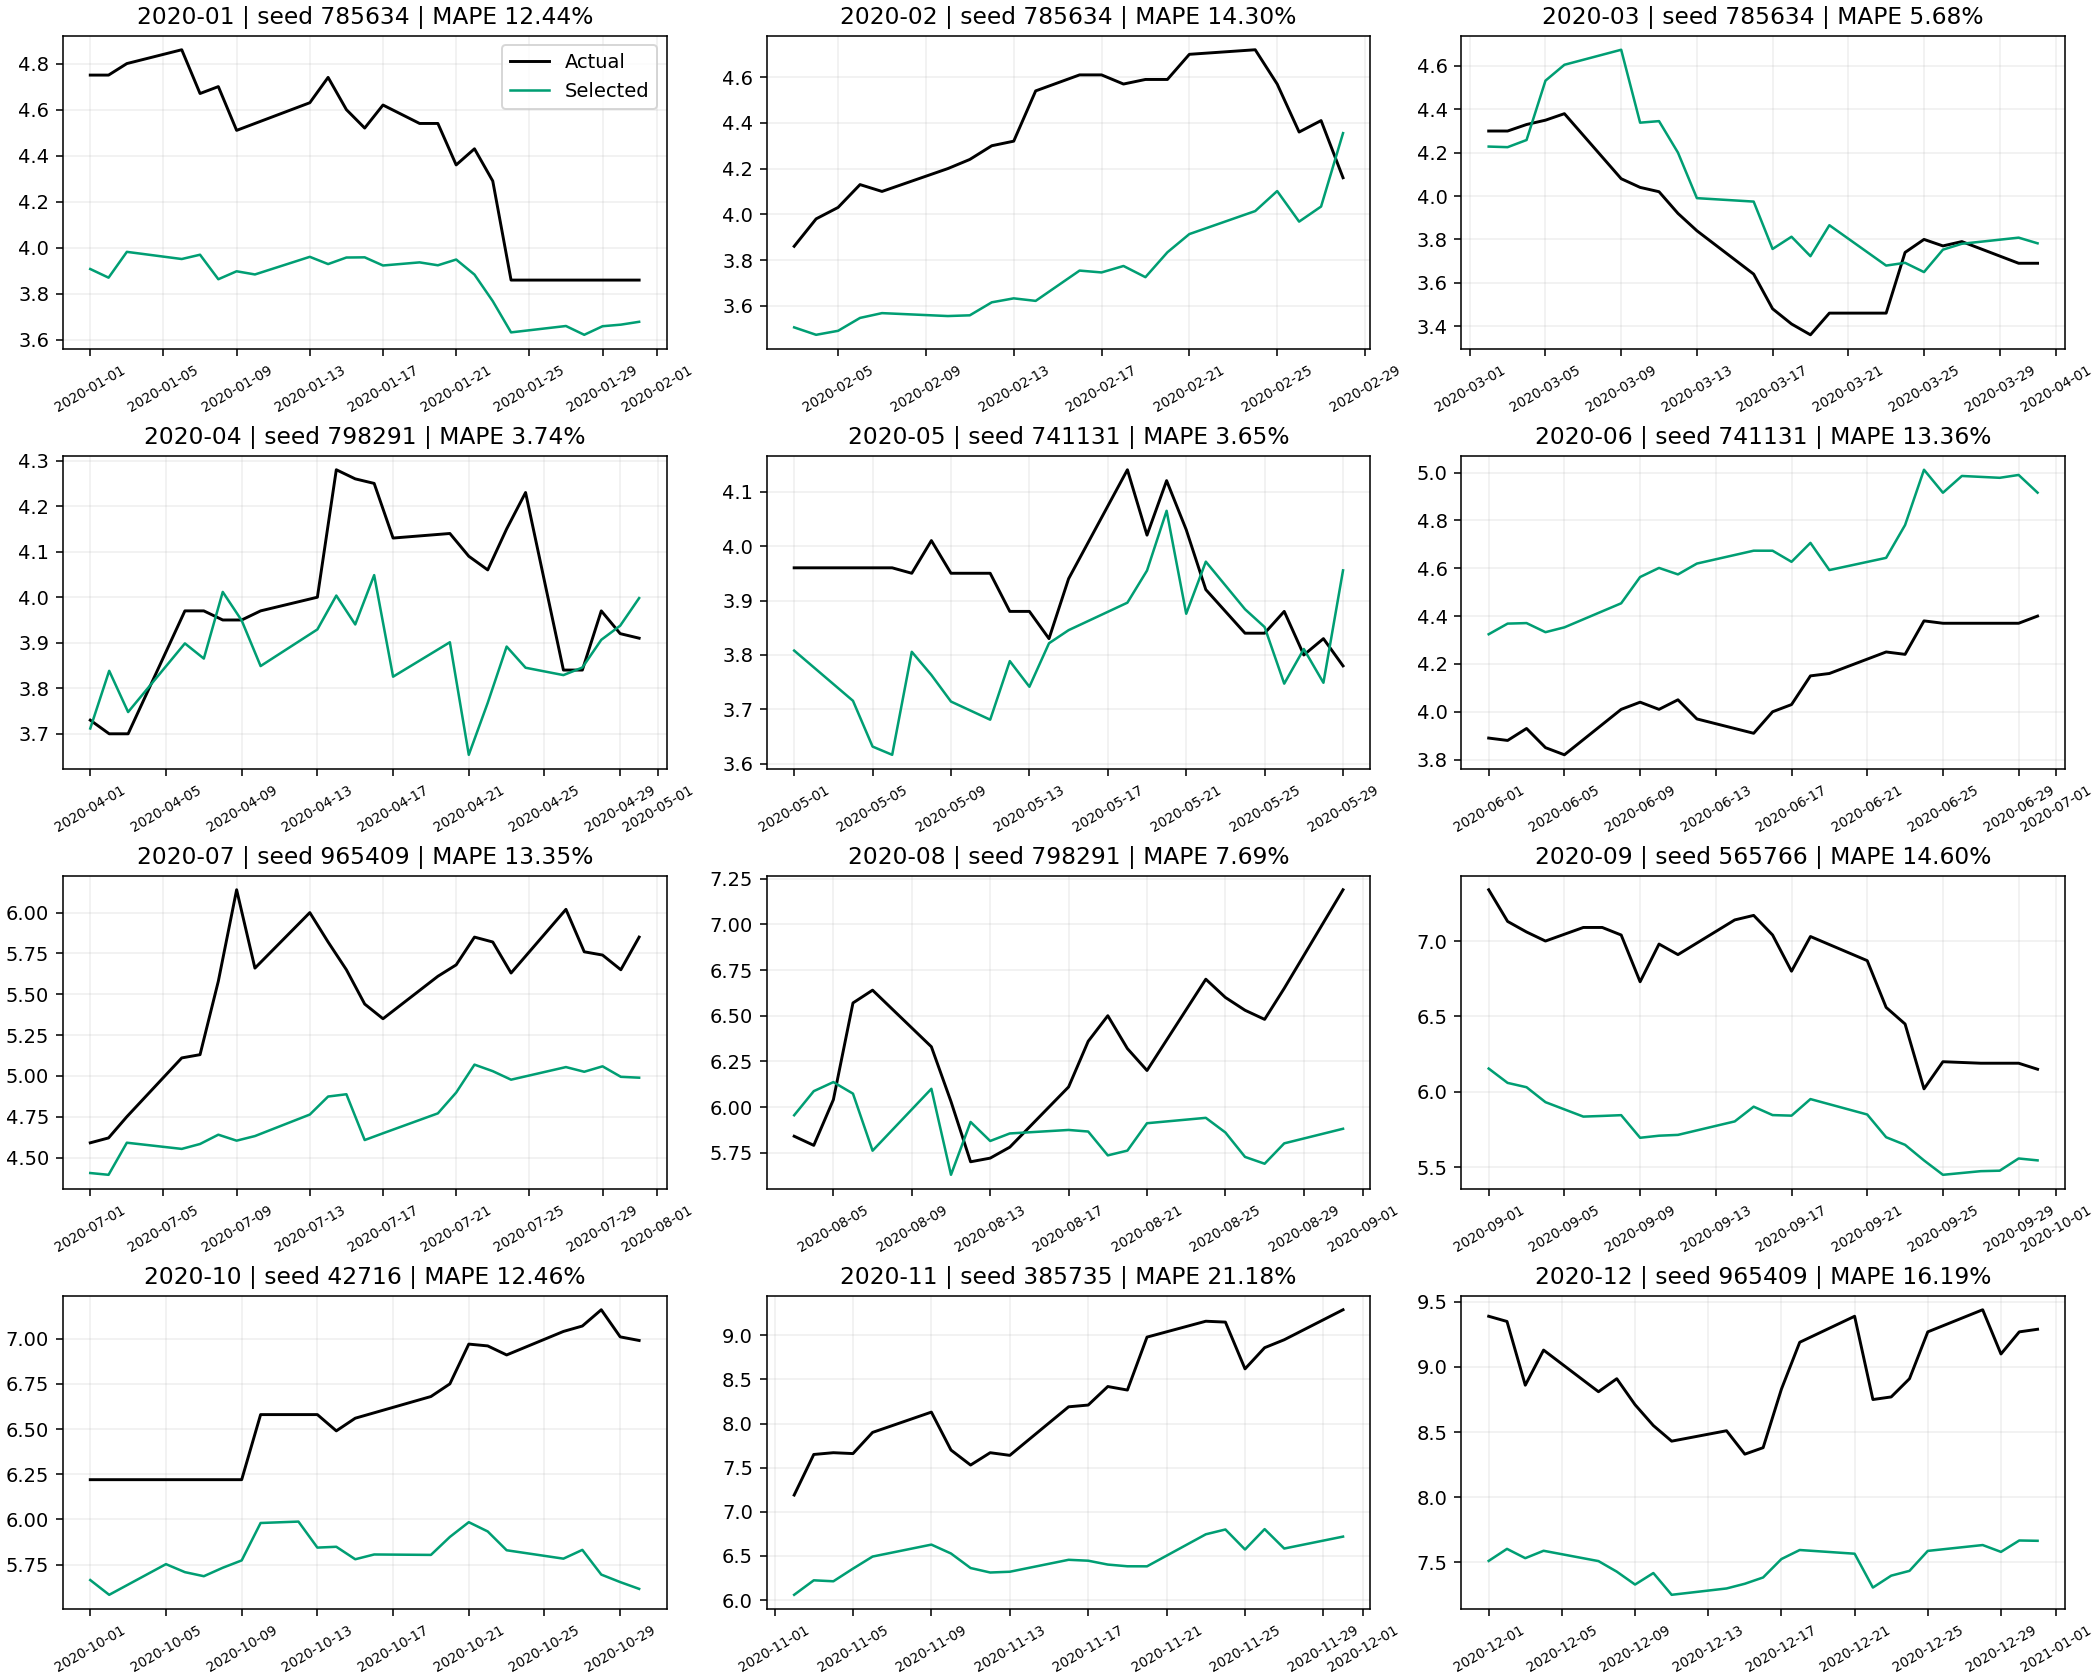

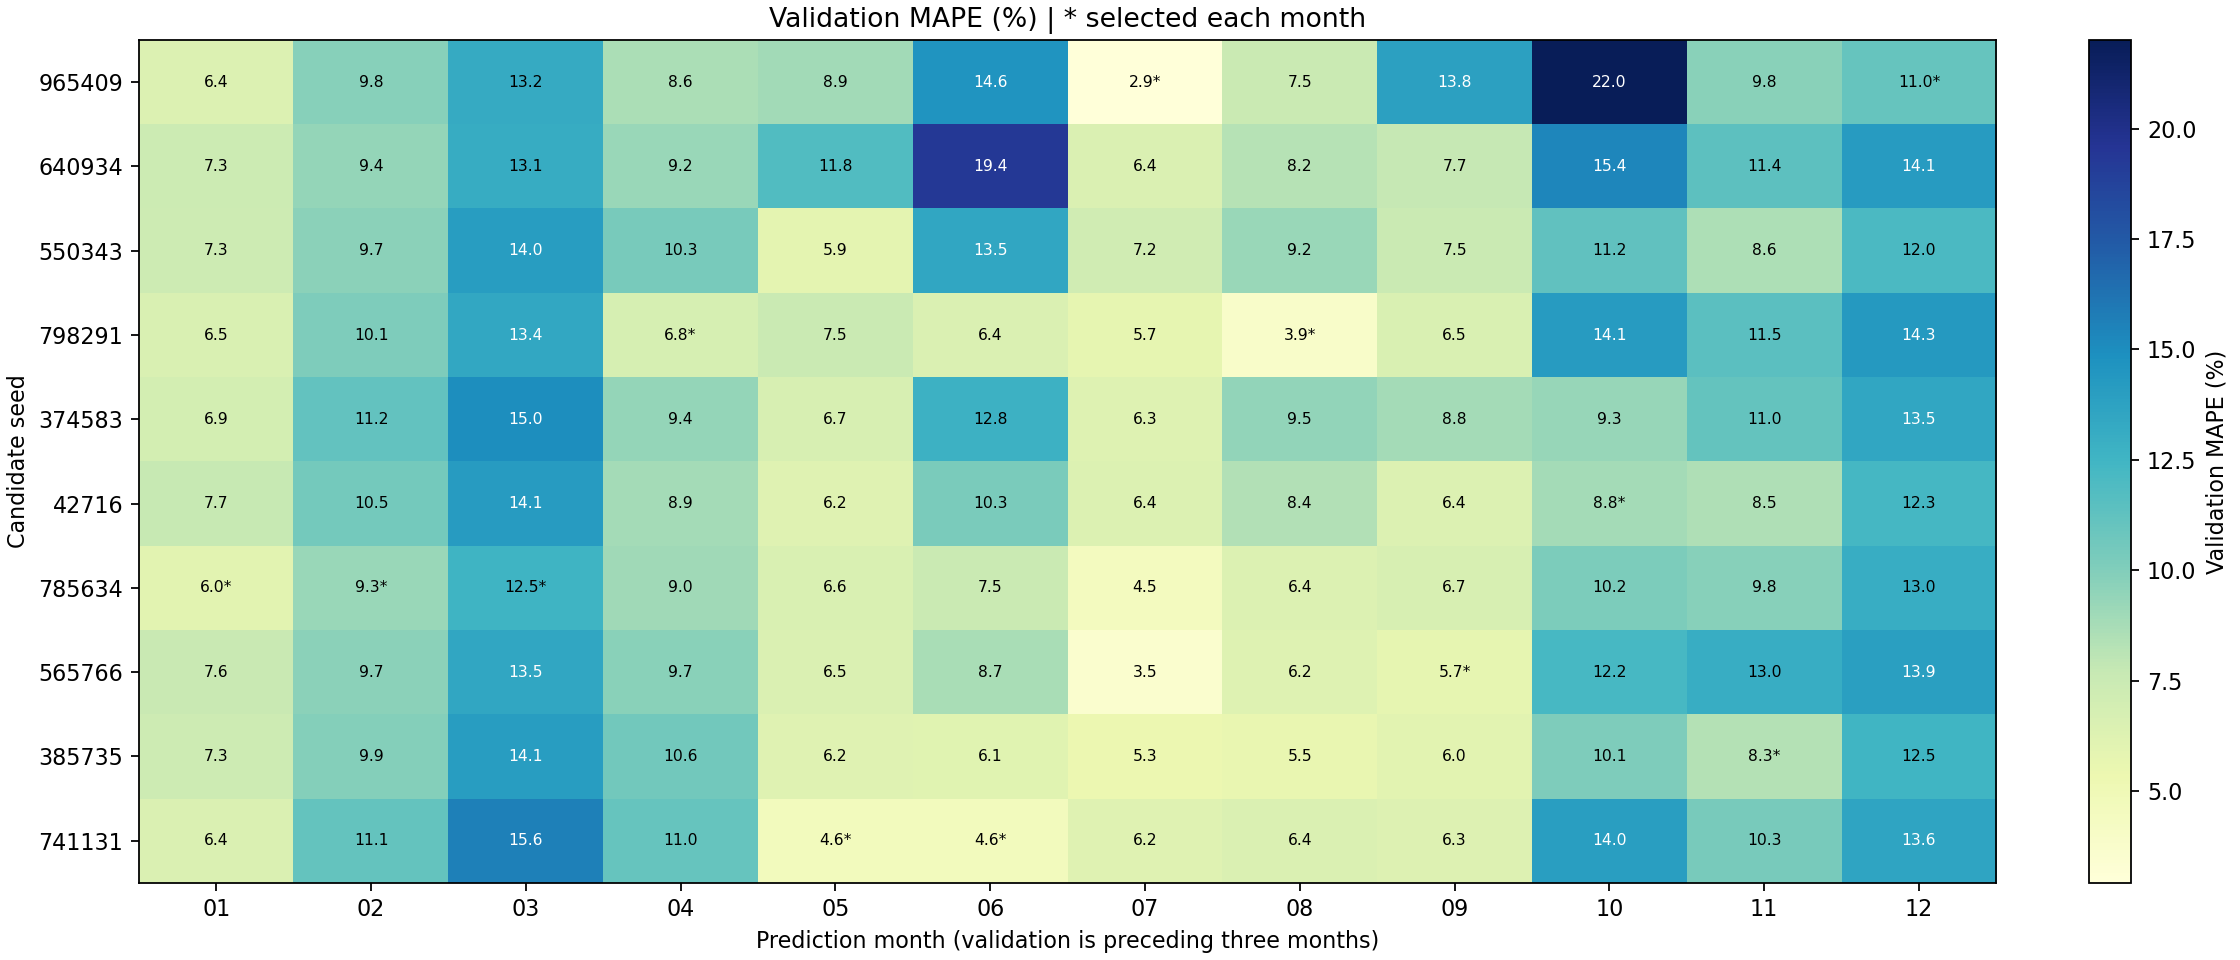

In [3]:
fig,axes=plt.subplots(2,1,figsize=(14,9),constrained_layout=True)
axes[0].plot(stitched.Date,stitched.Actual,color='black',lw=1.8,label='Actual')
axes[0].plot(stitched.Date,stitched.Predicted,color='#009E73',lw=1.5,label='Monthly train / validate / select')
axes[0].plot(stitched.Date,stitched.Frozen_annual_prediction,color='#0072B2',lw=1.2,alpha=.8,label=f'January model frozen (seed {annual_seed})')
for d in pd.date_range('2020-02-01','2020-12-01',freq='MS'):axes[0].axvline(d,color='gray',alpha=.15)
axes[0].set(title='2020 monthly stitched predictions | Stacking | 100 epochs per stage',ylabel='Price (dataset units)');axes[0].legend();axes[0].grid(alpha=.2)
positions=np.arange(12)
axes[1].bar(positions-.18,monthly.Test_MAPE,width=.35,color='#009E73',label='Monthly selection')
axes[1].bar(positions+.18,monthly.Frozen_annual_MAPE,width=.35,color='#0072B2',label='Frozen annual model')
axes[1].set(xticks=positions,xticklabels=[m[-2:] for m in monthly.Month],xlabel='2020 month',ylabel='Test MAPE (%)',title='Monthly test error');axes[1].legend();axes[1].grid(axis='y',alpha=.2)
fig.savefig(OUT/'stitched_comparison.png',dpi=160);plt.close(fig);display(Image(filename=str(OUT/'stitched_comparison.png')))
fig,axes=plt.subplots(4,3,figsize=(15,12),constrained_layout=True)
for ax,(month,g) in zip(axes.flat,stitched.groupby('Month')):
    ax.plot(g.Date,g.Actual,color='black',lw=1.5,label='Actual');ax.plot(g.Date,g.Predicted,color='#009E73',lw=1.3,label='Selected')
    r=monthly[monthly.Month==month].iloc[0]
    ax.set(title=f'{month} | seed {int(r.Selected_seed)} | MAPE {r.Test_MAPE:.2f}%');ax.grid(alpha=.2);ax.tick_params(axis='x',rotation=30,labelsize=7)
axes[0,0].legend();fig.savefig(OUT/'monthly_panels.png',dpi=140);plt.close(fig);display(Image(filename=str(OUT/'monthly_panels.png')))
rankmap=validation.pivot(index='Seed',columns='Month',values='MAPE').reindex(SEEDS)
fig,ax=plt.subplots(figsize=(14,6),constrained_layout=True)
im=ax.imshow(rankmap.to_numpy(),aspect='auto',cmap='YlGnBu')
ax.set(xticks=np.arange(12),xticklabels=[m[-2:] for m in rankmap.columns],yticks=np.arange(10),yticklabels=SEEDS,xlabel='Prediction month (validation is preceding three months)',ylabel='Candidate seed',title='Validation MAPE (%) | * selected each month')
for j,m in enumerate(rankmap.columns):
    chosen=int(selection.loc[selection.Month==m,'Selected_seed'].iloc[0])
    for i,s in enumerate(SEEDS):ax.text(j,i,f'{rankmap.loc[s,m]:.1f}'+('*' if s==chosen else ''),ha='center',va='center',fontsize=7,color='white' if rankmap.loc[s,m]>rankmap.to_numpy().max()*.6 else 'black')
fig.colorbar(im,ax=ax,label='Validation MAPE (%)');fig.savefig(OUT/'validation_heatmap.png',dpi=160);plt.close(fig);display(Image(filename=str(OUT/'validation_heatmap.png')))


## 逐月回测结论

| 月份 | 选中种子 | 前三月验证MAPE | 当月测试MAPE | 年初冻结模型MAPE |
|---|---:|---:|---:|---:|
|2020-01|785634|6.026%|12.442%|12.442%|
|2020-02|785634|9.254%|14.295%|12.933%|
|2020-03|785634|12.547%|5.680%|7.968%|
|2020-04|798291|6.791%|3.745%|3.195%|
|2020-05|741131|4.583%|3.650%|5.318%|
|2020-06|741131|4.616%|13.363%|8.446%|
|2020-07|965409|2.915%|13.347%|5.645%|
|2020-08|798291|3.853%|7.689%|14.355%|
|2020-09|565766|5.680%|14.598%|22.219%|
|2020-10|42716|8.844%|12.456%|20.554%|
|2020-11|385735|8.294%|21.183%|31.879%|
|2020-12|965409|10.996%|16.195%|30.328%|

| 方案 | 全年逐记录MAPE | 12个月等权MAPE | 全年原尺度MSE |
|---|---:|---:|---:|
|逐月训练、前三个月验证选种子|11.5270%|11.5536%|0.7955|
|1月选中模型全年冻结|14.5383%|14.6069%|1.7473|

逐月方案全年逐记录MAPE改善**3.0113个百分点**。1月两方案模型相同；3、5、8—12月改善，2、4、6、7月恶化，尤其6、7月分别比冻结方案高4.92、7.70个百分点。改进主要体现在8—12月，但11月仍有21.18%的测试MAPE，说明方法没有解决所有跨期误差。

本次结果支持“逐月更新整个训练与验证选择流程，比年初选择一次后全年固定更适应这一年”，不能单独证明选种子有效：训练数据每月扩展、验证窗口更新、模型选择变化同时发生。也不能据此认定3个月窗口优于6个月，6个月尚未运行。

10个候选随机种子已在结果出现前抽取、排除旧种子并固定到代码及配置；没有事后重抽种子。每月的selection.json先于当月评价写入；检查训练<验证<测试且三个区间无重叠；全年拼接覆盖原数据2020年全部271条记录、无重复无缺失；1月冻结对照与滚动方案预测一致（浮点容差1e-6）。

每个预测月前有3个月专用于验证且不参与本月训练。例如12月训练截至8月底，验证9—11月。选中后不重训是本次固定方案，意味着最新三个月用于选模型而非更新权重。

**仍需保留时间可用性限制**：模型使用测试日同日的宏观/金铜输入，这不是在月初提前生成整个月预测，而是冻结当月模型后用当日输入作回测。2020年也已用于此前实验，所以本次仍是开发期历史检验。

结果位于 `results/mlp_monthly_validation_12`，包括全年拼接图、12个月小图、验证热力图、逐月边界、候选验证排名、固定选择记录、各候选测试结果、240个阶段权重和训练历史。


---

目前没有把验证集也纳入训练,可能损失了一点信息,我们在进行一次比对.

---

# 固定上次逐月种子，纳入验证数据后重训对比

本节不重新选择种子：直接读取上一实验每月selection.csv中的种子。每个测试月M，把原训练与前三个月验证数据合并为M月之前的全部可用数据，重新拟合标准化器，并用既定种子从头初始化、训练两个阶段各100轮。不是在旧权重上继续加训100轮。

保留原模型结构、特征定义、样本起点、训练超参数、同日目标与测试日期。第二阶段仍用第一阶段样本内预测，不用折外预测。每月测试数据绝不进入重训或标准化。

对比：A上次选好种子直接预测、不重训；B同样种子纳入验证数据后从头重训。只重训每月选中的一个候选，共12个堆叠模型，不重跑10候选验证选择。复用原选择记录，不根据本次测试结果更换种子。

该对比同时反映新增训练数据及其引起的标准化/优化路径变化。最新三个月用于学习是否有益，由相同日期的样本外误差检验。仍是使用同日输入的历史回测，不是月初提前预测全部月内输入未知的股价。


In [1]:
from pathlib import Path
import os,json,hashlib,random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display,Image
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP12_REFIT_OUT',str(ROOT/'results/mlp_monthly_refit_12')));OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]
EXCLUDED_SEEDS=[0, 1, 7, 21, 42, 100, 123, 999, 2024, 2025]
EPOCHS=100;LR=0.01;VALIDATION_MONTHS=3
torch.set_num_threads(1);torch.use_deterministic_algorithms(True)
assert len(set(SEEDS))==10 and not set(SEEDS)&set(EXCLUDED_SEEDS)
dataset=ROOT/'src/pickle/Dataset.pkl';d=pd.read_pickle(dataset)
raw=d['X'].copy();target=d['Y'].copy();assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
raw=raw.loc[raw.index<'2021-01-01'];BASE=list(raw.columns);assert len(BASE)==7
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy();RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily';x[name]=raw[col]/raw[col].shift(1)-1;RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}';x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1;RETURNS.append(name)
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
x=x.loc[valid];y=y.loc[x.index];assert (y>0).all()
whole=x.index[x.index.year==2020];assert len(whole)==271
config=dict(seeds=SEEDS,excluded_prior_seeds=EXCLUDED_SEEDS,epochs_per_stage=EPOCHS,validation_months=VALIDATION_MONTHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions; base frozen',refit_after_selection=False,target='same-date original price',selection='minimum preceding-three-calendar-month MAPE; ties by candidate order',test_year=2020,dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
print('Frozen candidate seeds:',SEEDS)

PRIOR=OUT.parent/'mlp_monthly_validation_12'
if not (PRIOR/'selection.csv').exists():PRIOR=ROOT/'results/mlp_monthly_validation_12'
prior_config=json.loads((PRIOR/'config.json').read_text())
assert prior_config['dataset_sha256']==config['dataset_sha256'] and prior_config['seeds']==SEEDS
selection=pd.read_csv(PRIOR/'selection.csv')
original=pd.read_csv(PRIOR/'stitched_predictions.csv',parse_dates=['Date'])
assert len(selection)==12 and selection.Month.is_unique and len(original)==len(whole)
assert pd.DatetimeIndex(original.Date).equals(whole)
assert np.allclose(original.Actual,y.loc[whole])
config.update(refit_after_selection=True,seed_selection='reuse previous monthly selection.csv without reranking',refit='fresh initialization with selected seed; 100 epochs per stage',selection_sha256=hashlib.sha256((PRIOR/'selection.csv').read_bytes()).hexdigest())
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
selection.to_csv(OUT/'reused_selection.csv',index=False)
display(selection[['Month','Selected_seed','Validation_MAPE']])


,Month,Selected_seed,Validation_MAPE
0,2020-01,785634,6.025555
1,2020-02,785634,9.254464
2,2020-03,785634,12.546828
3,2020-04,798291,6.791479
4,2020-05,741131,4.583056
5,2020-06,741131,4.615878
6,2020-07,965409,2.915300
7,2020-08,798291,3.852990
8,2020-09,565766,5.680123
9,2020-10,42716,8.844333


Frozen candidate seeds: [965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]


In [2]:
history=[]
def fit_stage(X,train_idx,seed,stage,month):
    random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
    sx=StandardScaler().fit(X.loc[train_idx]);sy=StandardScaler().fit(y.loc[train_idx].to_numpy().reshape(-1,1))
    xt=torch.tensor(sx.transform(X.loc[train_idx]),dtype=torch.float32);yt=torch.tensor(sy.transform(y.loc[train_idx].to_numpy().reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    for epoch in range(1,EPOCHS+1):
        model.train();opt.zero_grad();loss=((model(xt)-yt)**2).mean();assert torch.isfinite(loss)
        loss.backward();opt.step();model.eval()
        with torch.no_grad():z=model(xt).numpy()
        p=sy.inverse_transform(z).ravel();mse=float(np.mean((p-y.loc[train_idx].to_numpy())**2))
        history.append(dict(Month=month,Seed=seed,Stage=stage,Epoch=epoch,Train_MSE=mse,Train_MSE_standardized=mse/float(sy.scale_[0]**2)))
    torch.save(dict(state_dict=model.state_dict(),features=list(X.columns),seed=seed,epochs=EPOCHS,train_start=str(train_idx.min()),train_end=str(train_idx.max()),sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist()),OUT/f'{month}_{stage}_seed{seed}.pt')
    return model,sx,sy

def predict(bundle,X):
    model,sx,sy=bundle;model.eval()
    with torch.no_grad():z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    p=sy.inverse_transform(z).ravel();assert np.isfinite(p).all();return pd.Series(p,index=X.index)

def score(pred,idx):
    err=pred.loc[idx].to_numpy()-y.loc[idx].to_numpy()
    return dict(N=len(idx),MAPE=float(100*np.mean(np.abs(err)/np.abs(y.loc[idx].to_numpy()))),MSE=float(np.mean(err**2)))

def stack_predict(base,stack,X):
    bp=predict(base,X[BASE]);meta=X[RETURNS].copy();meta.insert(0,'base_prediction',bp)
    return predict(stack,meta)

frames=[];splits=[];train_metrics=[]
for row in selection.itertuples(index=False):
    month=row.Month;seed=int(row.Selected_seed);start=pd.Timestamp(month+'-01');end=start+pd.DateOffset(months=1)
    tr=x.index[x.index<start];te=x.index[(x.index>=start)&(x.index<end)]
    assert tr.max()<te.min() and str(te.min().date())==row.Test_start and str(te.max().date())==row.Test_end
    assert tr.max()<=pd.Timestamp(row.Validation_end) and tr.min()==x.index.min()
    known=x.loc[tr]
    base=fit_stage(known[BASE],tr,seed,'Base',month)
    bp=predict(base,known[BASE]);meta=known[RETURNS].copy();meta.insert(0,'base_prediction',bp)
    stack=fit_stage(meta,tr,seed,'Stacking',month)
    pred=stack_predict(base,stack,x.loc[te]);train_pred=predict(stack,meta)
    train_metrics.append(dict(Month=month,Seed=seed,**score(train_pred,tr)))
    frames.append(pd.DataFrame(dict(Date=te,Month=month,Seed=seed,Actual=y.loc[te].to_numpy(),Refit_prediction=pred.to_numpy())))
    for split,idx in [('Refit_train',tr),('Test',te)]:splits.append(dict(Month=month,Split=split,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())))
    print(f'{month}: reused seed {seed}; refit {len(tr)} records; test {len(te)} records',flush=True)
refit=pd.concat(frames,ignore_index=True).sort_values('Date')
assert refit.Date.is_unique and pd.DatetimeIndex(refit.Date).equals(whole) and len(history)==2400
comparison=refit.merge(original[['Date','Month','Seed','Actual','Predicted']].rename(columns={'Predicted':'No_refit_prediction'}),on=['Date','Month','Seed'],suffixes=('','_old'),validate='one_to_one')
assert len(comparison)==len(whole) and np.allclose(comparison.Actual,comparison.Actual_old)
comparison=comparison.drop(columns='Actual_old')
comparison['Refit_APE']=100*np.abs(comparison.Refit_prediction-comparison.Actual)/comparison.Actual.abs()
comparison['No_refit_APE']=100*np.abs(comparison.No_refit_prediction-comparison.Actual)/comparison.Actual.abs()
monthly=comparison.groupby('Month').agg(Selected_seed=('Seed','first'),N=('Date','size'),No_refit_MAPE=('No_refit_APE','mean'),Refit_MAPE=('Refit_APE','mean'))
monthly['Refit_minus_no_refit_pp']=monthly.Refit_MAPE-monthly.No_refit_MAPE
monthly['Improved']=monthly.Refit_minus_no_refit_pp<0
summary=pd.DataFrame([dict(Method=label,Annual_daily_MAPE=comparison[ape].mean(),Monthly_equal_MAPE=monthly[col].mean(),Annual_MSE=np.mean((comparison[predcol]-comparison.Actual)**2)) for label,ape,col,predcol in [('No refit (previous selected models)','No_refit_APE','No_refit_MAPE','No_refit_prediction'),('Refit training plus validation','Refit_APE','Refit_MAPE','Refit_prediction')]])
assert np.isclose(summary.iloc[1].Annual_daily_MAPE,np.average(monthly.Refit_MAPE,weights=monthly.N))
old_monthly=pd.read_csv(PRIOR/'monthly_results.csv').set_index('Month')
assert np.allclose(monthly.No_refit_MAPE,old_monthly.Test_MAPE,atol=1e-5)
comparison.to_csv(OUT/'stitched_comparison.csv',index=False);monthly.to_csv(OUT/'monthly_comparison.csv');summary.to_csv(OUT/'summary.csv',index=False)
pd.DataFrame(history).to_csv(OUT/'training_history.csv',index=False);pd.DataFrame(train_metrics).to_csv(OUT/'refit_train_metrics.csv',index=False);pd.DataFrame(splits).to_csv(OUT/'splits.csv',index=False)
print('Monthly paired results (negative difference is improvement):');display(monthly.round(4))
print('Annual summary:');display(summary.round(4))
print(f'Refit improved {int(monthly.Improved.sum())}/12 months')


,Selected_seed,N,No_refit_MAPE,Refit_MAPE,Refit_minus_no_refit_pp,Improved
Month,,,,,,
2020-01,785634,24,12.4420,8.4636,-3.9784,True
2020-02,785634,21,14.2954,6.2803,-8.0151,True
2020-03,785634,22,5.6804,10.8491,5.1687,False
2020-04,798291,23,3.7448,7.3819,3.6371,False
2020-05,741131,23,3.6497,4.2413,0.5916,False
2020-06,741131,23,13.3628,9.2889,-4.0738,True
2020-07,965409,23,13.3470,14.0170,0.6700,False
2020-08,798291,21,7.6893,5.4751,-2.2143,True
2020-09,565766,24,14.5983,11.4930,-3.1053,True


,Method,Annual_daily_MAPE,Monthly_equal_MAPE,Annual_MSE
0,No refit (previous selected models),11.5270,11.5536,0.7955
1,Refit training plus validation,8.1499,8.1528,0.3381


2020-01: reused seed 785634; refit 2035 records; test 24 records
2020-02: reused seed 785634; refit 2059 records; test 21 records
2020-03: reused seed 785634; refit 2080 records; test 22 records
2020-04: reused seed 798291; refit 2102 records; test 23 records
2020-05: reused seed 741131; refit 2125 records; test 23 records
2020-06: reused seed 741131; refit 2148 records; test 23 records
2020-07: reused seed 965409; refit 2171 records; test 23 records
2020-08: reused seed 798291; refit 2194 records; test 21 records
2020-09: reused seed 565766; refit 2215 records; test 24 records
2020-10: reused seed 42716; refit 2239 records; test 23 records
2020-11: reused seed 385735; refit 2262 records; test 21 records
2020-12: reused seed 965409; refit 2283 records; test 23 records
Monthly paired results (negative difference is improvement):
Annual summary:
Refit improved 8/12 months


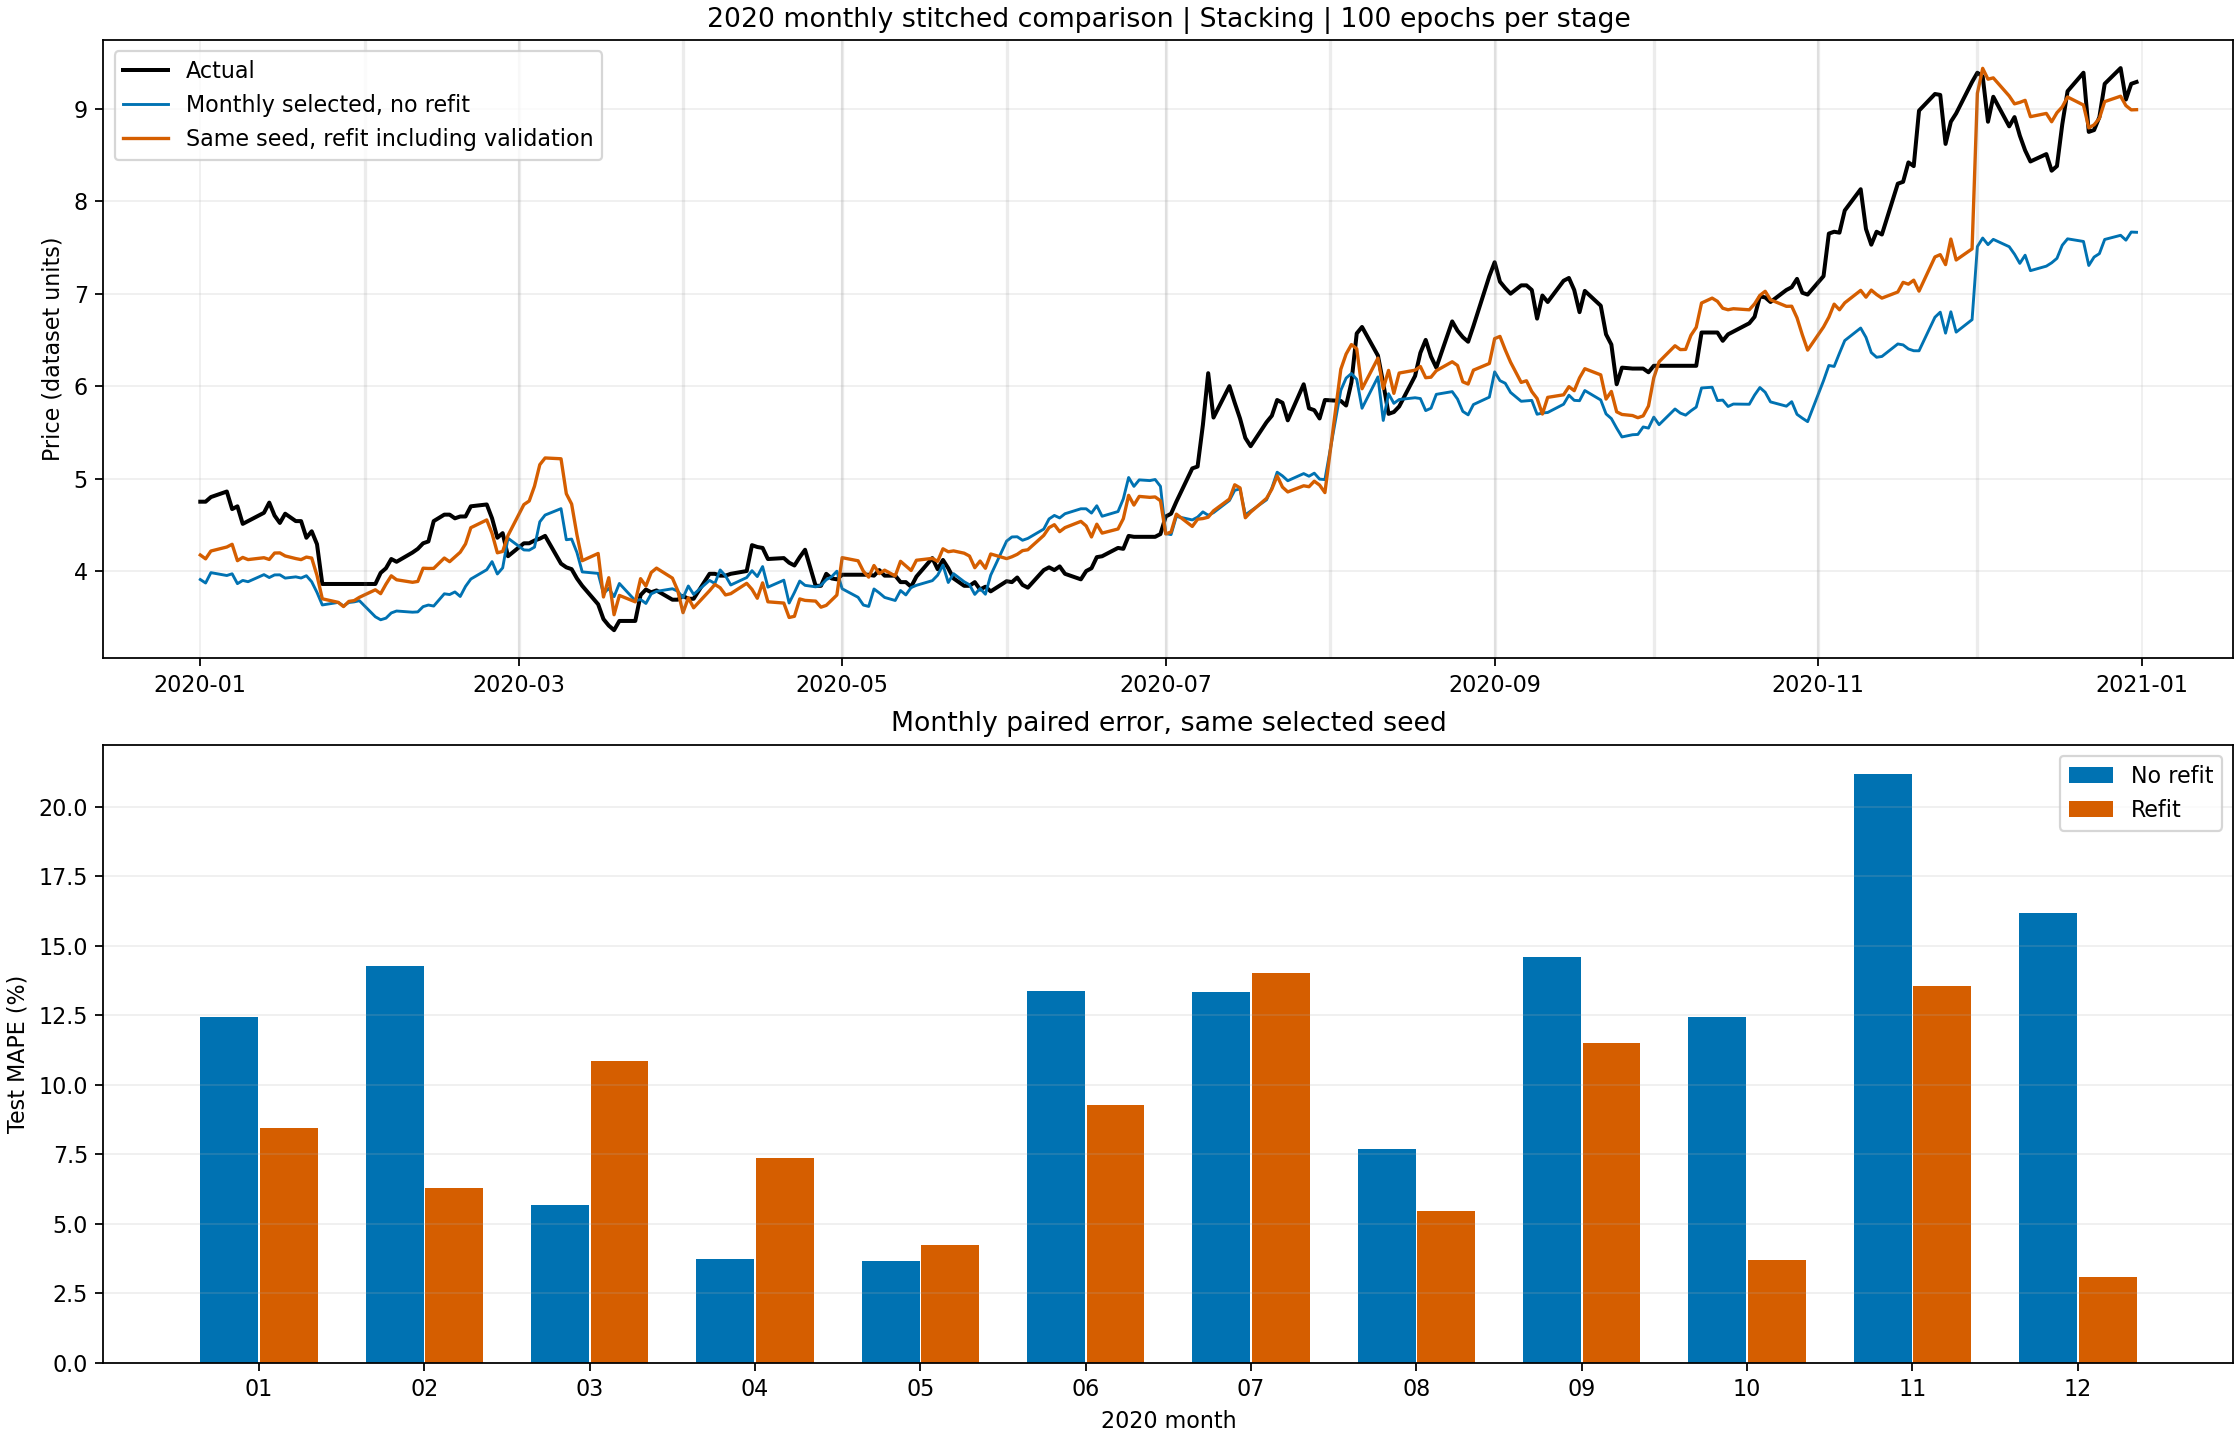

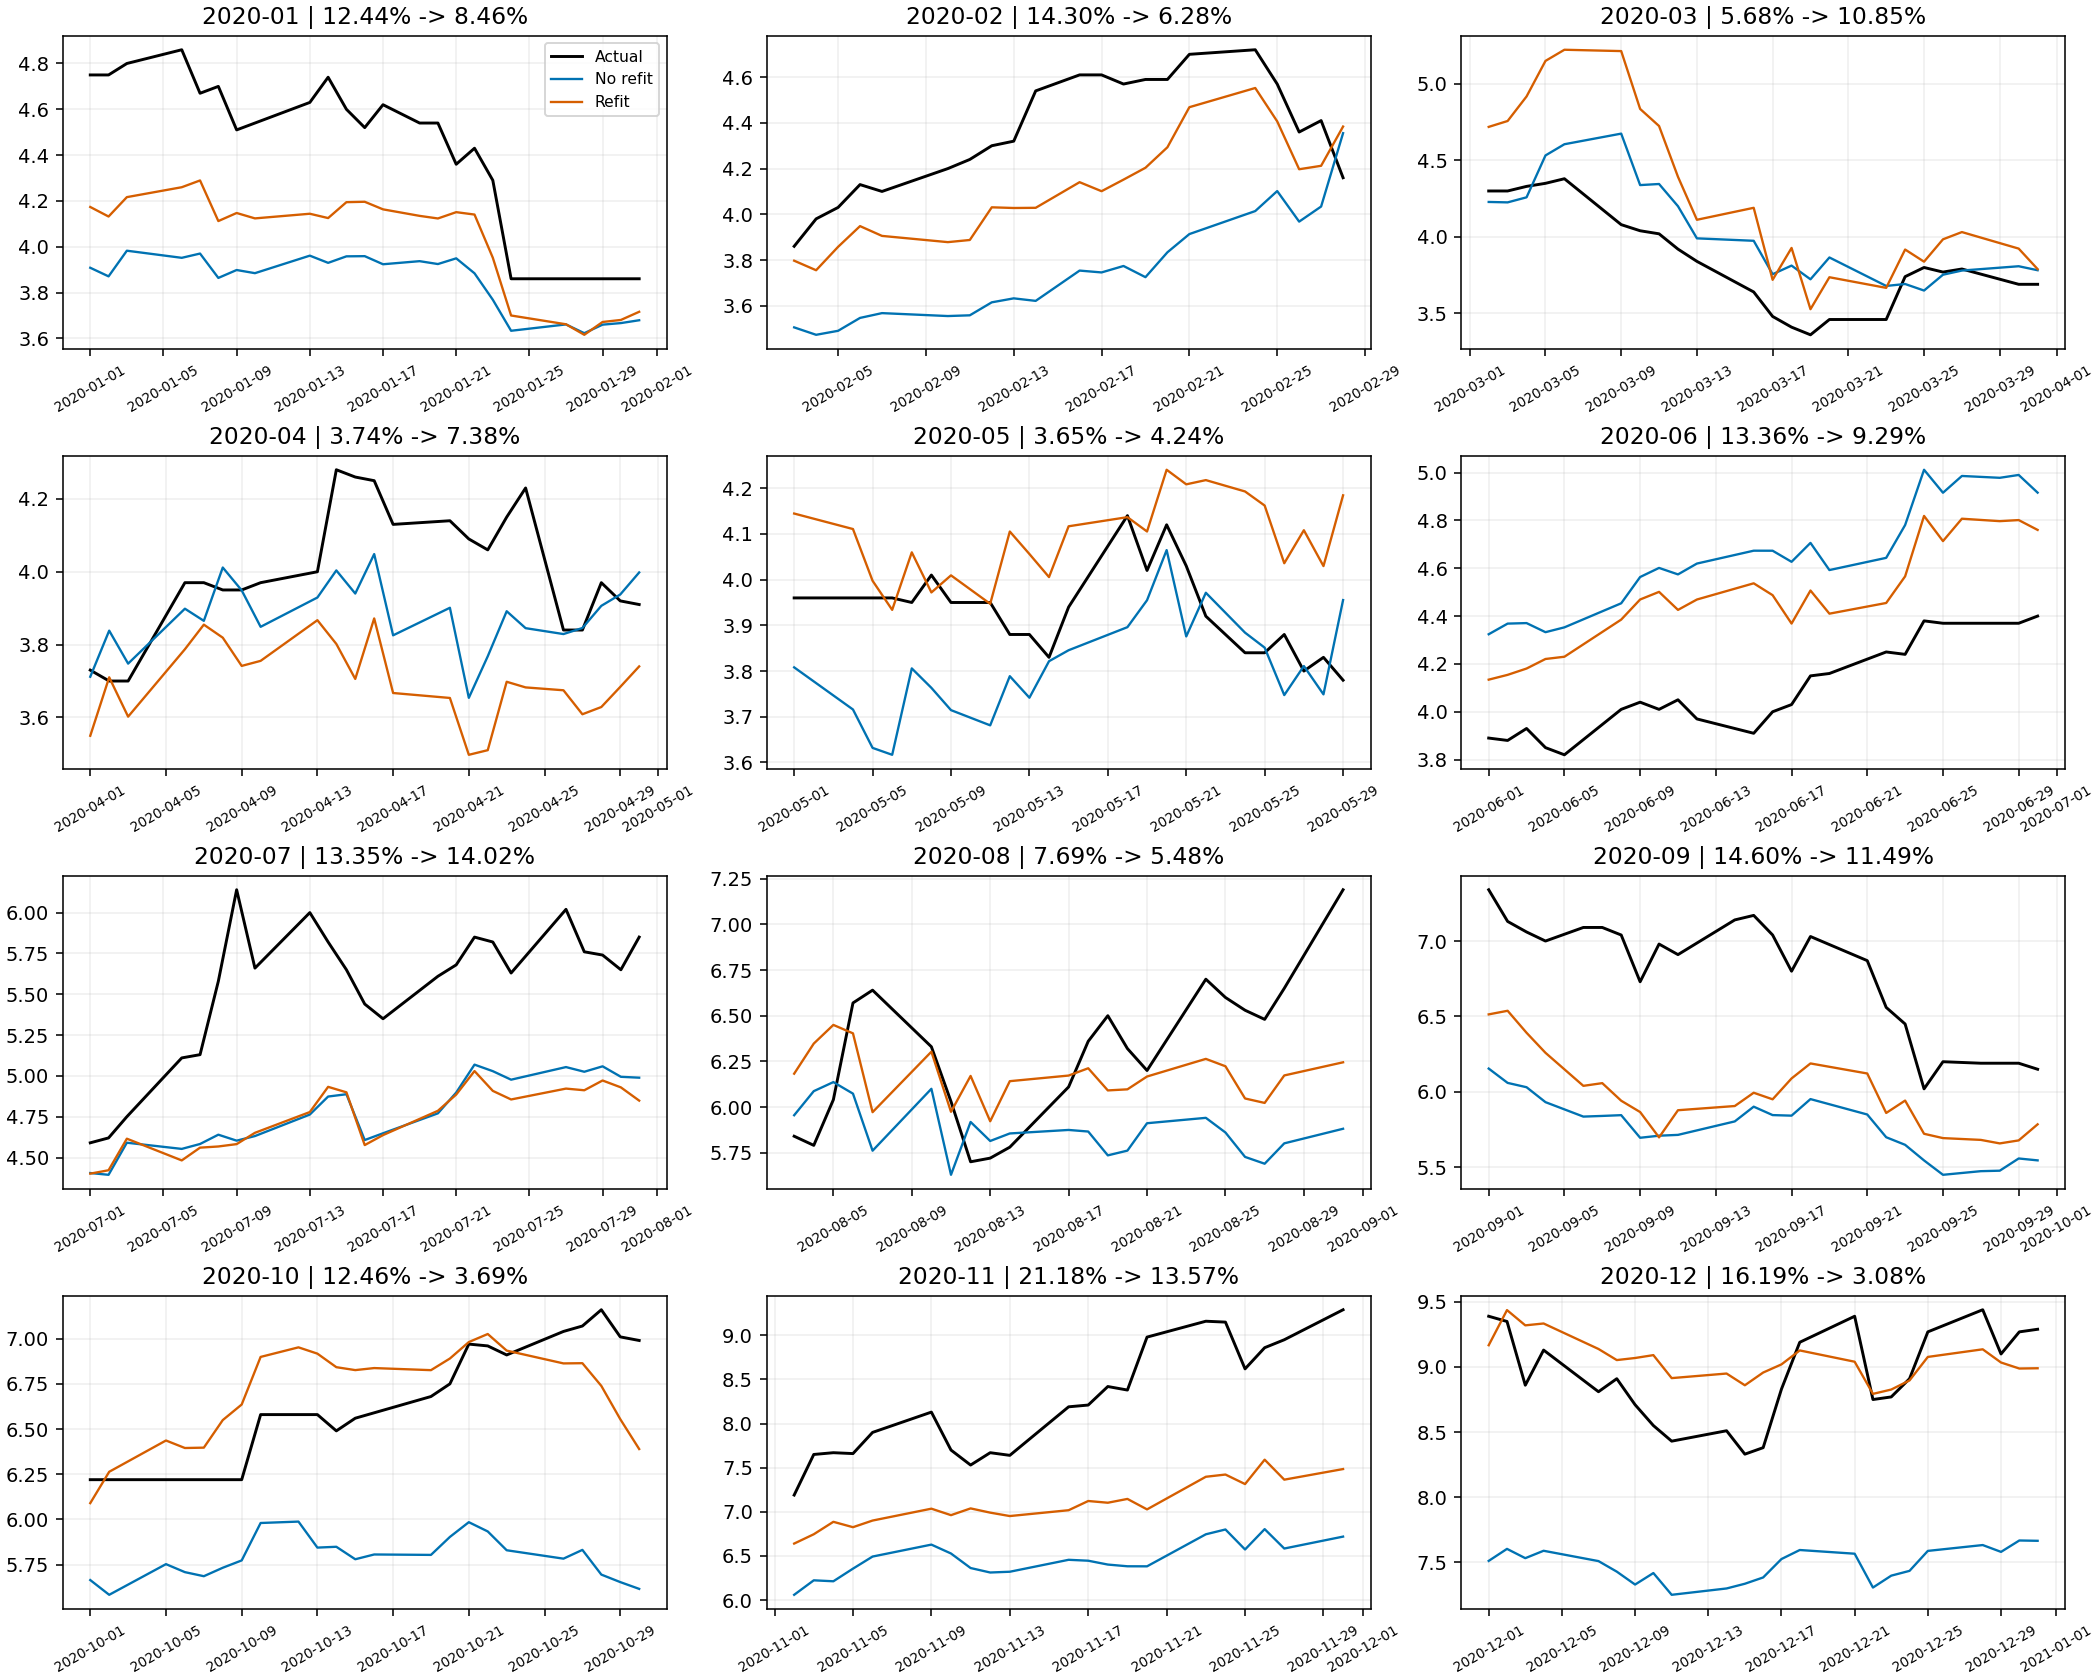

In [3]:
fig,axes=plt.subplots(2,1,figsize=(14,9),constrained_layout=True)
axes[0].plot(comparison.Date,comparison.Actual,color='black',lw=1.8,label='Actual')
axes[0].plot(comparison.Date,comparison.No_refit_prediction,color='#0072B2',lw=1.3,label='Monthly selected, no refit')
axes[0].plot(comparison.Date,comparison.Refit_prediction,color='#D55E00',lw=1.5,label='Same seed, refit including validation')
for d in pd.date_range('2020-02-01','2020-12-01',freq='MS'):axes[0].axvline(d,color='gray',alpha=.15)
axes[0].set(title='2020 monthly stitched comparison | Stacking | 100 epochs per stage',ylabel='Price (dataset units)');axes[0].legend();axes[0].grid(alpha=.2)
pos=np.arange(12)
axes[1].bar(pos-.18,monthly.No_refit_MAPE,width=.35,color='#0072B2',label='No refit')
axes[1].bar(pos+.18,monthly.Refit_MAPE,width=.35,color='#D55E00',label='Refit')
axes[1].set(xticks=pos,xticklabels=[m[-2:] for m in monthly.index],xlabel='2020 month',ylabel='Test MAPE (%)',title='Monthly paired error, same selected seed');axes[1].legend();axes[1].grid(axis='y',alpha=.2)
fig.savefig(OUT/'refit_comparison.png',dpi=160);plt.close(fig);display(Image(filename=str(OUT/'refit_comparison.png')))
fig,axes=plt.subplots(4,3,figsize=(15,12),constrained_layout=True)
for ax,(month,g) in zip(axes.flat,comparison.groupby('Month')):
    ax.plot(g.Date,g.Actual,color='black',lw=1.5,label='Actual');ax.plot(g.Date,g.No_refit_prediction,color='#0072B2',lw=1.2,label='No refit');ax.plot(g.Date,g.Refit_prediction,color='#D55E00',lw=1.2,label='Refit')
    r=monthly.loc[month]
    ax.set(title=f'{month} | {r.No_refit_MAPE:.2f}% -> {r.Refit_MAPE:.2f}%');ax.grid(alpha=.2);ax.tick_params(axis='x',rotation=30,labelsize=7)
axes[0,0].legend(fontsize=8);fig.savefig(OUT/'monthly_panels.png',dpi=140);plt.close(fig);display(Image(filename=str(OUT/'monthly_panels.png')))


## 纳入验证集重训的结果

| 月份 | 固定种子 | 不重训MAPE | 纳入验证集重训MAPE | 重训−不重训（百分点） |
|---|---:|---:|---:|---:|
|2020-01|785634|12.442%|8.464%|-3.978|
|2020-02|785634|14.295%|6.280%|-8.015|
|2020-03|785634|5.680%|10.849%|+5.169|
|2020-04|798291|3.745%|7.382%|+3.637|
|2020-05|741131|3.650%|4.241%|+0.592|
|2020-06|741131|13.363%|9.289%|-4.074|
|2020-07|965409|13.347%|14.017%|+0.670|
|2020-08|798291|7.689%|5.475%|-2.214|
|2020-09|565766|14.598%|11.493%|-3.105|
|2020-10|42716|12.456%|3.691%|-8.765|
|2020-11|385735|21.183%|13.574%|-7.610|
|2020-12|965409|16.195%|3.079%|-13.116|

| 方案 | 全年逐记录MAPE | 月度等权平均MAPE | 全年原股价尺度MSE |
|---|---:|---:|---:|
|原选中模型直接预测，不重训|11.5270%|11.5536%|0.7955|
|固定种子，加入验证数据后从头重训|8.1499%|8.1528%|0.3381|

全年MAPE降低3.3771个百分点，约相对降低29.3%。12个月中8个月改善；3、4、5、7月变差。改善较大的是12月（−13.12个百分点）、10月（−8.76）、2月（−8.02）、11月（−7.61）。因此，本次历史实验支持利用最近三个月重新训练能够改善总体表现，但并非每个月必然改善。

本次完全复用上一实验每个月的种子，不再进行10候选选择。标准化器和两个阶段的权重均在合并后的训练数据上重新拟合/初始化，各100轮。结果不能解释为旧模型继续训练的收益，也不能单独分离“新增样本”和“标准化、优化路径变化”的贡献。

每月测试集均在重训数据之后；全年271条记录无重复无缺失，与不重训结果按日期/月/种子一一配对。旧结果保持不变，新输出位于 `results/mlp_monthly_refit_12`，包括重训权重、训练历史、拼接预测、月度对照图及汇总。

仍为使用同日金铜等输入的样本外历史回测；2020年已经被反复研究，需在未参与开发的时期验证能否推广。


但是如果是一个月更新一次权重,会让跳变非常突兀,且只有在月末才更新.

应该设计一个更新条件.

# 股价、黄金、铜：统一尺度与滚动涨幅（Plotly Express）

展示2020年。上图三条价格统一换算为**2020年首条记录=100**，因此比较的是累计相对走势，非原始价格单位；金铜5/20期滚动均价用相同基准换算，在图例中点击可显示。均价在全年历史上计算后再截取2020，不在年初重新起算。

下方分别展示黄金、铜的3项模型涨幅：相邻一期P(t)/P(t−1)−1、相对5期均价P(t)/MA5(t)−1、相对20期均价P(t)/MA20(t)−1，均乘100以百分数展示。两个涨幅面板使用完全一致的纵轴范围，方便比较幅度；价格指数和百分比是不同量纲，不共用同一个纵轴。

滚动均价包含当日，窗口按原数据记录计数。图支持拖动缩放、悬停查看、点击图例切换曲线，底部日期滑块联动三个面板；“全部”按钮恢复全年。原数据使用原Dataset的价格口径，不额外改变复权和日期对齐。


In [1]:
from pathlib import Path
import os,json
import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import display
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT_PX=Path(os.environ.get('MLP12_PX_OUT',str(ROOT/'results/price_metal_plotly_12')));OUT_PX.mkdir(parents=True,exist_ok=True)
d=pd.read_pickle(ROOT/'src/pickle/Dataset.pkl');raw=d['X'].copy();target=d['Y']
assert raw.index.equals(target.index) and raw.index.is_unique and raw.index.is_monotonic_increasing
prices=pd.DataFrame({'股价':np.asarray(target).reshape(-1),'黄金':raw['Gold Futures Price'].to_numpy(),'铜':raw['Copper Futures Price'].to_numpy()},index=raw.index)
ma={k:prices[['黄金','铜']].rolling(k,min_periods=k).mean() for k in [5,20]}
returns={}
for metal in ['黄金','铜']:
    returns[f'{metal} · 昨日涨跌幅']=100*(prices[metal]/prices[metal].shift(1)-1)
    for k in [5,20]:returns[f'{metal} · 相对MA{k}涨幅']=100*(prices[metal]/ma[k][metal]-1)
idx=prices.index[prices.index.year==2020];assert len(idx)==271
base=prices.loc[idx[0]];indexed=100*prices.loc[idx]/base
ret=pd.DataFrame(returns).loc[idx];assert np.isfinite(ret.to_numpy()).all()
panels=['价格指数（年初=100）','黄金涨跌幅（%）','铜涨跌幅（%）']
frames=[]
for col in prices:
    frames.append(pd.DataFrame({'日期':idx,'数值':indexed[col].to_numpy(),'曲线':col,'面板':panels[0]}))
for metal in ['黄金','铜']:
    for k in [5,20]:
        frames.append(pd.DataFrame({'日期':idx,'数值':(100*ma[k].loc[idx,metal]/base[metal]).to_numpy(),'曲线':f'{metal} MA{k}','面板':panels[0]}))
for name,values in ret.items():
    frames.append(pd.DataFrame({'日期':idx,'数值':values.to_numpy(),'曲线':name,'面板':panels[1] if name.startswith('黄金') else panels[2]}))
plotdata=pd.concat(frames,ignore_index=True)
colors={'股价':'#222222','黄金':'#D59400','铜':'#0072B2','黄金 MA5':'#D59400','黄金 MA20':'#D59400','铜 MA5':'#0072B2','铜 MA20':'#0072B2'}
for metal in ['黄金','铜']:
    colors.update({f'{metal} · 昨日涨跌幅':'#9AA0A6',f'{metal} · 相对MA5涨幅':'#009E73',f'{metal} · 相对MA20涨幅':'#CC79A7'})
fig_px=px.line(plotdata,x='日期',y='数值',color='曲线',facet_row='面板',category_orders={'面板':panels,'曲线':list(colors)},color_discrete_map=colors,render_mode='svg',height=1050,title='2020｜股价与金铜价格、滚动均价及涨跌幅')
# px facet_row按类别顺序从上到下排列：yaxis3价格，yaxis2黄金，yaxis铜。
assert next(t for t in fig_px.data if t.name=='股价').yaxis=='y3'
fig_px.update_yaxes(matches=None,showticklabels=True)
limit=float(np.abs(ret.to_numpy()).max()*1.08)
fig_px.update_layout(yaxis=dict(title='涨跌幅 (%)',range=[-limit,limit],ticksuffix='%',zeroline=True,zerolinecolor='#888'),yaxis2=dict(title='涨跌幅 (%)',range=[-limit,limit],matches='y',ticksuffix='%',zeroline=True,zerolinecolor='#888'),yaxis3=dict(title='价格指数',zeroline=False))
for trace in fig_px.data:
    if trace.name.endswith('MA5') and ' · ' not in trace.name:trace.visible='legendonly';trace.line.dash='dash'
    if trace.name.endswith('MA20') and ' · ' not in trace.name:trace.visible='legendonly';trace.line.dash='dot'
    trace.line.width=1.6 if trace.name!='股价' else 2.2
    unit='%' if ' · ' in trace.name else ''
    trace.hovertemplate='%{x|%Y-%m-%d}<br>'+trace.name+': %{y:.2f}'+unit+'<extra></extra>'
fig_px.for_each_annotation(lambda a:a.update(text=a.text.split('=')[1] if a.text.startswith('面板=') else a.text))
# 上述分隔按第一个等号切分，保留“年初=100”文本。
for a,panel in zip(fig_px.layout.annotations,reversed(panels)):a.text=panel
fig_px.update_xaxes(matches='x',showticklabels=True,title_text=None)
fig_px.update_layout(template='plotly_white',hovermode='x unified',font=dict(family='Arial, PingFang SC, Microsoft YaHei, sans-serif'),margin=dict(l=80,r=245,t=85,b=80),legend=dict(title='点击切换；双击单独显示',x=1.05,y=1,font=dict(size=11)),xaxis=dict(title='日期',rangeslider=dict(visible=True,thickness=.065),rangeselector=dict(buttons=[dict(count=1,label='1个月',step='month',stepmode='backward'),dict(count=3,label='3个月',step='month',stepmode='backward'),dict(count=6,label='6个月',step='month',stepmode='backward'),dict(label='全部',step='all')],y=-.24)),xaxis2=dict(rangeslider=dict(visible=False)),xaxis3=dict(rangeslider=dict(visible=False)))
config_px={'displaylogo':False,'scrollZoom':True,'responsive':True,'toImageButtonOptions':{'filename':'2020_price_metals','format':'png','scale':2}}
fig_px.write_html(OUT_PX/'2020_price_metals_interactive.html',include_plotlyjs=True,config=config_px)
fig_px.write_json(OUT_PX/'figure.json')
prices.loc[idx].join(indexed.add_suffix('_年初100')).join(ret).to_csv(OUT_PX/'chart_data.csv',index_label='Date')
plotdata.to_csv(OUT_PX/'plot_long_data.csv',index=False)
(OUT_PX/'config.json').write_text(json.dumps({'year':2020,'price_base_date':str(idx[0].date()),'price_base_values':base.to_dict(),'return_y_range':[-limit,limit],'ma_includes_current':True,'windows':[5,20]},ensure_ascii=False,indent=2))
assert len(fig_px.data)==13 and all(np.isclose(indexed.iloc[0],100))
assert fig_px.layout.yaxis.range==fig_px.layout.yaxis2.range
# 本图六项涨幅须与12中模型输入逐条一致。
prior=ROOT/'results/mlp_monthly_validation_12/features_and_target.csv'
if prior.exists():
    old=pd.read_csv(prior,index_col='Date',parse_dates=True).loc[idx]
    for metal,eng in [('黄金','gold'),('铜','copper')]:
        assert np.allclose(ret[f'{metal} · 昨日涨跌幅'],100*old[f'{eng}_daily'])
        for k in [5,20]:assert np.allclose(ret[f'{metal} · 相对MA{k}涨幅'],100*old[f'{eng}_vs_ma{k}'])
    print('复核通过：六项涨幅与12中的模型输入一致。')
display(fig_px)
print('上面价格基准为2020年首条记录=100；均价线默认隐藏，点击图例可显示。')


复核通过：六项涨幅与12中的模型输入一致。
上面价格基准为2020年首条记录=100；均价线默认隐藏，点击图例可显示。


新增规则,一个月更新一次太慢.无法准确抓住变化.以金铜价格偏离5日20日的滚动平均为触发条件.

金或铜与20日偏离3%更新一次,超出3%则更新权重,回落则再更新一次.

# 金铜MA20偏离回归正常后触发更新：次日选种子并重训

沿用2020年、既定10个新种子、两阶段Stacking、每阶段100轮和此前特征。**触发改为回归正常**：对金、铜分别观察 `abs(P/MA20−1)`；达到或超过3%为偏离状态，后来首次回到严格小于3%时触发。一直正常不触发，一直超标不反复触发；若再次超标后又回归，可再次触发。两金属独立判断，同一日触发合并为一次更新，即使另一金属尚未正常也更新。

在触发日收盘后确认信号，在**下一条有效数据记录开始时**执行更新并应用新模型；本数据含非交易日记录，不能将“下一条记录”直接称作下一A股交易日。触发日仍由旧模型预测。没有冷却期或阈值缓冲带。

更新流程：以生效日之前最近3个日历月为验证期，更早全部有效数据为候选训练期；十个种子各训练两阶段100轮，选验证MAPE最低者；合并训练与验证，再用所选种子从头训练两阶段各100轮。所有标准化仅拟合对应训练区间，新模型从生效日开始使用，直到下次更新。测试当天真实股价不得进入当天选种子或训练。

年初2020-01-01按同样流程建立初始模型，单独计数；年度触发次数、实际更新次数、金/铜各自次数均记录。如果年末触发后数据中没有下一条2020记录，则记录为待执行、不计入年内实际更新。

对照上一节“每月验证选种子＋合并验证数据重训”。两个方案使用同样种子与训练设置，区别在更新时点和相应验证窗口。

仍沿用同日金铜等输入，因此是收盘输入条件下的历史样本外回测，而非在当天开始时已知当天股价预测；更新训练本身只用生效日前的数据。该年曾参与开发，结论不能当作全新盲测。


In [1]:
from pathlib import Path
import os,json,hashlib,random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display,Image
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP12_REENTRY_OUT',str(ROOT/'results/mlp_reentry_update_12')));OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]
EXCLUDED_SEEDS=[0, 1, 7, 21, 42, 100, 123, 999, 2024, 2025]
EPOCHS=100;LR=0.01;VALIDATION_MONTHS=3
torch.set_num_threads(1);torch.use_deterministic_algorithms(True)
assert len(set(SEEDS))==10 and not set(SEEDS)&set(EXCLUDED_SEEDS)
dataset=ROOT/'src/pickle/Dataset.pkl';d=pd.read_pickle(dataset)
raw=d['X'].copy();target=d['Y'].copy();assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
raw=raw.loc[raw.index<'2021-01-01'];BASE=list(raw.columns);assert len(BASE)==7
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy();RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily';x[name]=raw[col]/raw[col].shift(1)-1;RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}';x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1;RETURNS.append(name)
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
x=x.loc[valid];y=y.loc[x.index];assert (y>0).all()
whole=x.index[x.index.year==2020];assert len(whole)==271
config=dict(seeds=SEEDS,excluded_prior_seeds=EXCLUDED_SEEDS,epochs_per_stage=EPOCHS,validation_months=VALIDATION_MONTHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions; base frozen',refit_after_selection=False,target='same-date original price',selection='minimum preceding-three-calendar-month MAPE; ties by candidate order',test_year=2020,dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
print('Frozen candidate seeds:',SEEDS)

THRESHOLD=.03
config.update(trigger='individual metal abs(MA20 deviation) re-enters below 3% after at least 3%; same-date events merged',threshold=THRESHOLD,effective='next available record',refit_after_selection=True,validation_window='three calendar months immediately before effective date',cooldown=None)
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
# 在完整历史计算状态，使2020年初状态继承自2019年；只执行2020年触发。
deviations=x[['gold_vs_ma20','copper_vs_ma20']]
outside=deviations.abs().ge(THRESHOLD)
reentry=outside.shift(1,fill_value=False)&~outside
trigger_dates=reentry.index[(reentry.any(axis=1))&(reentry.index.year==2020)]
eventrows=[]
for day in trigger_dates:
    pos=x.index.get_loc(day);nextday=x.index[pos+1] if pos+1<len(x) else pd.NaT
    executable=pd.notna(nextday) and nextday.year==2020
    eventrows.append(dict(Trigger_date=day,Effective_date=nextday,Gold_trigger=bool(reentry.loc[day,'gold_vs_ma20']),Copper_trigger=bool(reentry.loc[day,'copper_vs_ma20']),Gold_deviation_percent=100*deviations.loc[day,'gold_vs_ma20'],Copper_deviation_percent=100*deviations.loc[day,'copper_vs_ma20'],Executable_in_2020=executable))
events=pd.DataFrame(eventrows)
events.to_csv(OUT/'trigger_events.csv',index=False)
schedule=[dict(Update_ID='initial',Kind='Initial',Trigger_date=pd.NaT,Effective_date=whole.min())]
for i,r in enumerate(events[events.Executable_in_2020].itertuples(index=False),1):
    schedule.append(dict(Update_ID=f'update_{i:02d}',Kind='Triggered',Trigger_date=r.Trigger_date,Effective_date=r.Effective_date))
schedule=pd.DataFrame(schedule).sort_values('Effective_date').reset_index(drop=True)
assert schedule.Effective_date.is_unique
print(f'触发日 {len(events)} 次；年内计划更新 {len(schedule)-1} 次；另有年初初始化1次。')
display(events)


,Trigger_date,Effective_date,Gold_trigger,Copper_trigger,Gold_deviation_percent,Copper_deviation_percent,Executable_in_2020
0,2020-01-09,2020-01-10,True,False,2.612086,-0.349417,True
1,2020-02-11,2020-02-12,False,True,-0.023948,-2.475336,True
2,2020-02-26,2020-02-27,True,False,2.854205,-0.374539,True
3,2020-03-10,2020-03-11,True,False,1.984865,-2.341254,True
4,2020-03-23,2020-03-24,True,False,-1.450880,-14.156688,True
5,2020-03-25,2020-03-26,True,False,2.637787,-8.486962,True
6,2020-03-27,2020-03-30,True,False,1.885693,-8.366996,True
7,2020-04-06,2020-04-07,False,True,5.042988,-1.765870,True
8,2020-04-17,2020-04-20,True,False,1.481488,5.238452,True
9,2020-04-21,2020-04-22,False,True,0.360607,-0.117691,True


Frozen candidate seeds: [965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]
触发日 29 次；年内计划更新 29 次；另有年初初始化1次。


In [2]:
history=[]
def fit_stage(X,train_idx,seed,stage,month):
    random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
    sx=StandardScaler().fit(X.loc[train_idx]);sy=StandardScaler().fit(y.loc[train_idx].to_numpy().reshape(-1,1))
    xt=torch.tensor(sx.transform(X.loc[train_idx]),dtype=torch.float32);yt=torch.tensor(sy.transform(y.loc[train_idx].to_numpy().reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    for epoch in range(1,EPOCHS+1):
        model.train();opt.zero_grad();loss=((model(xt)-yt)**2).mean();assert torch.isfinite(loss)
        loss.backward();opt.step();model.eval()
        with torch.no_grad():z=model(xt).numpy()
        p=sy.inverse_transform(z).ravel();mse=float(np.mean((p-y.loc[train_idx].to_numpy())**2))
        history.append(dict(Update_ID=month,Seed=seed,Stage=stage,Epoch=epoch,Train_MSE=mse,Train_MSE_standardized=mse/float(sy.scale_[0]**2)))
    torch.save(dict(state_dict=model.state_dict(),features=list(X.columns),seed=seed,epochs=EPOCHS,train_start=str(train_idx.min()),train_end=str(train_idx.max()),sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist()),OUT/f'{month}_{stage}_seed{seed}.pt')
    return model,sx,sy

def predict(bundle,X):
    model,sx,sy=bundle;model.eval()
    with torch.no_grad():z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    p=sy.inverse_transform(z).ravel();assert np.isfinite(p).all();return pd.Series(p,index=X.index)

def score(pred,idx):
    err=pred.loc[idx].to_numpy()-y.loc[idx].to_numpy()
    return dict(N=len(idx),MAPE=float(100*np.mean(np.abs(err)/np.abs(y.loc[idx].to_numpy()))),MSE=float(np.mean(err**2)))

def stack_predict(base,stack,X):
    bp=predict(base,X[BASE]);meta=X[RETURNS].copy();meta.insert(0,'base_prediction',bp)
    return predict(stack,meta)

all_rankings=[];updates=[];frames=[];splitrows=[]
for j,row in enumerate(schedule.itertuples(index=False)):
    tag=row.Update_ID;effective=pd.Timestamp(row.Effective_date)
    stop=pd.Timestamp(schedule.iloc[j+1].Effective_date) if j+1<len(schedule) else pd.Timestamp('2021-01-01')
    val_start=effective-pd.DateOffset(months=VALIDATION_MONTHS)
    tr=x.index[x.index<val_start];va=x.index[(x.index>=val_start)&(x.index<effective)];refit_idx=x.index[x.index<effective]
    applied=x.index[(x.index>=effective)&(x.index<stop)]
    assert len(tr)>0 and len(va)>0 and len(applied)>0 and tr.max()<va.min() and va.max()<effective
    assert refit_idx.max()<effective and tr.union(va).equals(refit_idx)
    if row.Kind=='Triggered':
        assert refit_idx.max()==row.Trigger_date
        assert x.index[x.index.get_loc(row.Trigger_date)+1]==effective
    known=x.loc[refit_idx];candidates=[]
    for i,seed in enumerate(SEEDS):
        base=fit_stage(known[BASE],tr,seed,'CandidateBase',tag)
        bp=predict(base,known[BASE]);meta=known[RETURNS].copy();meta.insert(0,'base_prediction',bp)
        stack=fit_stage(meta,tr,seed,'CandidateStacking',tag)
        vp=predict(stack,meta)
        candidates.append(dict(Update_ID=tag,Seed=seed,Candidate_order=i,**score(vp,va)))
    ranking=pd.DataFrame(candidates).sort_values(['MAPE','Candidate_order']).reset_index(drop=True)
    ranking['Rank']=np.arange(1,11);chosen=int(ranking.iloc[0].Seed);ranking['Selected']=ranking.Seed.eq(chosen)
    all_rankings.append(ranking)
    decision=dict(Update_ID=tag,Kind=row.Kind,Trigger_date=None if pd.isna(row.Trigger_date) else str(row.Trigger_date.date()),Effective_date=str(effective.date()),Selected_seed=chosen,Validation_MAPE=float(ranking.iloc[0].MAPE),Candidate_train_end=str(tr.max().date()),Validation_start=str(va.min().date()),Validation_end=str(va.max().date()),Refit_train_end=str(refit_idx.max().date()),Refit_N=len(refit_idx))
    # 固定选择记录后，从头在训练+验证上重训；不读生效日真实股价。
    (OUT/f'{tag}_selection.json').write_text(json.dumps(decision,ensure_ascii=False,indent=2))
    final_base=fit_stage(known[BASE],refit_idx,chosen,'RefitBase',tag)
    bp=predict(final_base,known[BASE]);meta=known[RETURNS].copy();meta.insert(0,'base_prediction',bp)
    final_stack=fit_stage(meta,refit_idx,chosen,'RefitStacking',tag)
    pred=stack_predict(final_base,final_stack,x.loc[applied])
    updates.append(dict(**decision,Applied_end=str(applied.max().date()),Applied_N=len(applied),Applied_MAPE=score(pred,applied)['MAPE']))
    frames.append(pd.DataFrame(dict(Date=applied,Update_ID=tag,Seed=chosen,Actual=y.loc[applied].to_numpy(),Predicted=pred.to_numpy())))
    for split,idx in [('Candidate_train',tr),('Validation',va),('Refit_train',refit_idx),('Applied_test',applied)]:splitrows.append(dict(Update_ID=tag,Split=split,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())))
    print(f'{tag}: effective {effective.date()}, seed {chosen}, validation {ranking.iloc[0].MAPE:.3f}%, train through {refit_idx.max().date()}',flush=True)

stitched=pd.concat(frames,ignore_index=True).sort_values('Date')
assert stitched.Date.is_unique and pd.DatetimeIndex(stitched.Date).equals(whole)
assert len(history)==len(schedule)*(len(SEEDS)+1)*2*EPOCHS
stitched['APE']=100*np.abs(stitched.Predicted-stitched.Actual)/stitched.Actual.abs();stitched['Month']=stitched.Date.dt.strftime('%Y-%m')
monthly=stitched.groupby('Month').agg(N=('Date','size'),Event_MAPE=('APE','mean'))
PRIOR=OUT.parent/'mlp_monthly_refit_12'
if not (PRIOR/'stitched_comparison.csv').exists():PRIOR=ROOT/'results/mlp_monthly_refit_12'
old=pd.read_csv(PRIOR/'stitched_comparison.csv',parse_dates=['Date'])
check=stitched.merge(old[['Date','Actual','Refit_prediction']],on='Date',suffixes=('','_old'),validate='one_to_one')
assert len(check)==len(whole) and np.allclose(check.Actual,check.Actual_old)
stitched['Monthly_refit_prediction']=check.Refit_prediction.to_numpy()
stitched['Monthly_refit_APE']=100*np.abs(stitched.Monthly_refit_prediction-stitched.Actual)/stitched.Actual.abs()
monthly['Monthly_refit_MAPE']=stitched.groupby('Month').Monthly_refit_APE.mean()
monthly['Event_minus_monthly_pp']=monthly.Event_MAPE-monthly.Monthly_refit_MAPE
# 初始化与原1月合并验证重训使用同一规则，首个更新前应复现其预测。
first=stitched.Update_ID=='initial';assert np.allclose(stitched.loc[first,'Predicted'],stitched.loc[first,'Monthly_refit_prediction'],atol=1e-5,rtol=0)
counts=dict(Gold_reentries=int(events.Gold_trigger.sum()),Copper_reentries=int(events.Copper_trigger.sum()),Merged_trigger_days=len(events),Triggered_updates=int((schedule.Kind=='Triggered').sum()),Pending_after_2020=int((~events.Executable_in_2020).sum()),Initializations=1,Total_deployed_models=len(schedule),Candidate_models_trained=len(schedule)*len(SEEDS),Refit_models_trained=len(schedule),Total_stage_trainings=len(schedule)*(len(SEEDS)+1)*2)
summary=pd.DataFrame([dict(Method='Return-to-normal updates',Annual_daily_MAPE=stitched.APE.mean(),Monthly_equal_MAPE=monthly.Event_MAPE.mean(),Annual_MSE=np.mean((stitched.Predicted-stitched.Actual)**2),Updates_excluding_initial=counts['Triggered_updates']),dict(Method='Monthly selected seed + refit',Annual_daily_MAPE=stitched.Monthly_refit_APE.mean(),Monthly_equal_MAPE=monthly.Monthly_refit_MAPE.mean(),Annual_MSE=np.mean((stitched.Monthly_refit_prediction-stitched.Actual)**2),Updates_excluding_initial=11)])
assert np.isclose(stitched.APE.mean(),np.average(monthly.Event_MAPE,weights=monthly.N))
for name,frame in [('stitched_predictions',stitched),('updates',pd.DataFrame(updates)),('validation_ranking',pd.concat(all_rankings,ignore_index=True)),('splits',pd.DataFrame(splitrows)),('summary',summary),('training_history',pd.DataFrame(history))]:frame.to_csv(OUT/f'{name}.csv',index=False)
monthly.to_csv(OUT/'monthly_comparison.csv');(OUT/'update_counts.json').write_text(json.dumps(counts,indent=2))
print('更新次数（初始化单列）：',counts);display(pd.DataFrame(updates));display(monthly.round(4));display(summary.round(4))


,Update_ID,Kind,Trigger_date,Effective_date,Selected_seed,Validation_MAPE,Candidate_train_end,Validation_start,Validation_end,Refit_train_end,Refit_N,Applied_end,Applied_N,Applied_MAPE
0,initial,Initial,None,2020-01-01,785634,6.025555,2019-09-30,2019-10-01,2019-12-31,2019-12-31,2035,2020-01-09,7,11.195788
1,update_01,Triggered,2020-01-09,2020-01-10,785634,6.758838,2019-10-09,2019-10-10,2020-01-09,2020-01-09,2042,2020-02-11,24,3.805879
2,update_02,Triggered,2020-02-11,2020-02-12,785634,10.214028,2019-11-11,2019-11-12,2020-02-11,2020-02-11,2066,2020-02-26,12,6.449482
3,update_03,Triggered,2020-02-26,2020-02-27,785634,12.301034,2019-11-26,2019-11-27,2020-02-26,2020-02-26,2078,2020-03-10,9,16.301759
4,update_04,Triggered,2020-03-10,2020-03-11,785634,11.998093,2019-12-10,2019-12-11,2020-03-10,2020-03-10,2087,2020-03-23,9,3.754169
5,update_05,Triggered,2020-03-23,2020-03-24,798291,8.734533,2019-12-23,2019-12-24,2020-03-23,2020-03-23,2096,2020-03-25,2,6.247270
6,update_06,Triggered,2020-03-25,2020-03-26,798291,7.859909,2019-12-25,2019-12-26,2020-03-25,2020-03-25,2098,2020-03-27,2,2.947263
7,update_07,Triggered,2020-03-27,2020-03-30,798291,7.119129,2019-12-27,2019-12-30,2020-03-27,2020-03-27,2100,2020-04-06,6,2.260708
8,update_08,Triggered,2020-04-06,2020-04-07,42716,6.618998,2020-01-06,2020-01-07,2020-04-06,2020-04-06,2106,2020-04-17,9,4.110065
9,update_09,Triggered,2020-04-17,2020-04-20,741131,4.155203,2020-01-19,2020-01-20,2020-04-17,2020-04-17,2115,2020-04-21,2,3.290637


,N,Event_MAPE,Monthly_refit_MAPE,Event_minus_monthly_pp
Month,,,,
2020-01,24,5.0876,8.4636,-3.3760
2020-02,21,6.6448,6.2803,0.3646
2020-03,22,8.4778,10.8491,-2.3713
2020-04,23,3.8593,7.3819,-3.5226
2020-05,23,3.8080,4.2413,-0.4333
2020-06,23,8.2015,9.2889,-1.0874
2020-07,23,9.5440,14.0170,-4.4730
2020-08,21,5.7081,5.4751,0.2330
2020-09,24,8.1207,11.4930,-3.3723


,Method,Annual_daily_MAPE,Monthly_equal_MAPE,Annual_MSE,Updates_excluding_initial
0,Return-to-normal updates,6.7342,6.7733,0.2595,29
1,Monthly selected seed + refit,8.1499,8.1528,0.3381,11


initial: effective 2020-01-01, seed 785634, validation 6.026%, train through 2019-12-31
update_01: effective 2020-01-10, seed 785634, validation 6.759%, train through 2020-01-09
update_02: effective 2020-02-12, seed 785634, validation 10.214%, train through 2020-02-11
update_03: effective 2020-02-27, seed 785634, validation 12.301%, train through 2020-02-26
update_04: effective 2020-03-11, seed 785634, validation 11.998%, train through 2020-03-10
update_05: effective 2020-03-24, seed 798291, validation 8.735%, train through 2020-03-23
update_06: effective 2020-03-26, seed 798291, validation 7.860%, train through 2020-03-25
update_07: effective 2020-03-30, seed 798291, validation 7.119%, train through 2020-03-27
update_08: effective 2020-04-07, seed 42716, validation 6.619%, train through 2020-04-06
update_09: effective 2020-04-20, seed 741131, validation 4.155%, train through 2020-04-17
update_10: effective 2020-04-22, seed 741131, validation 4.218%, train through 2020-04-21
update_11:

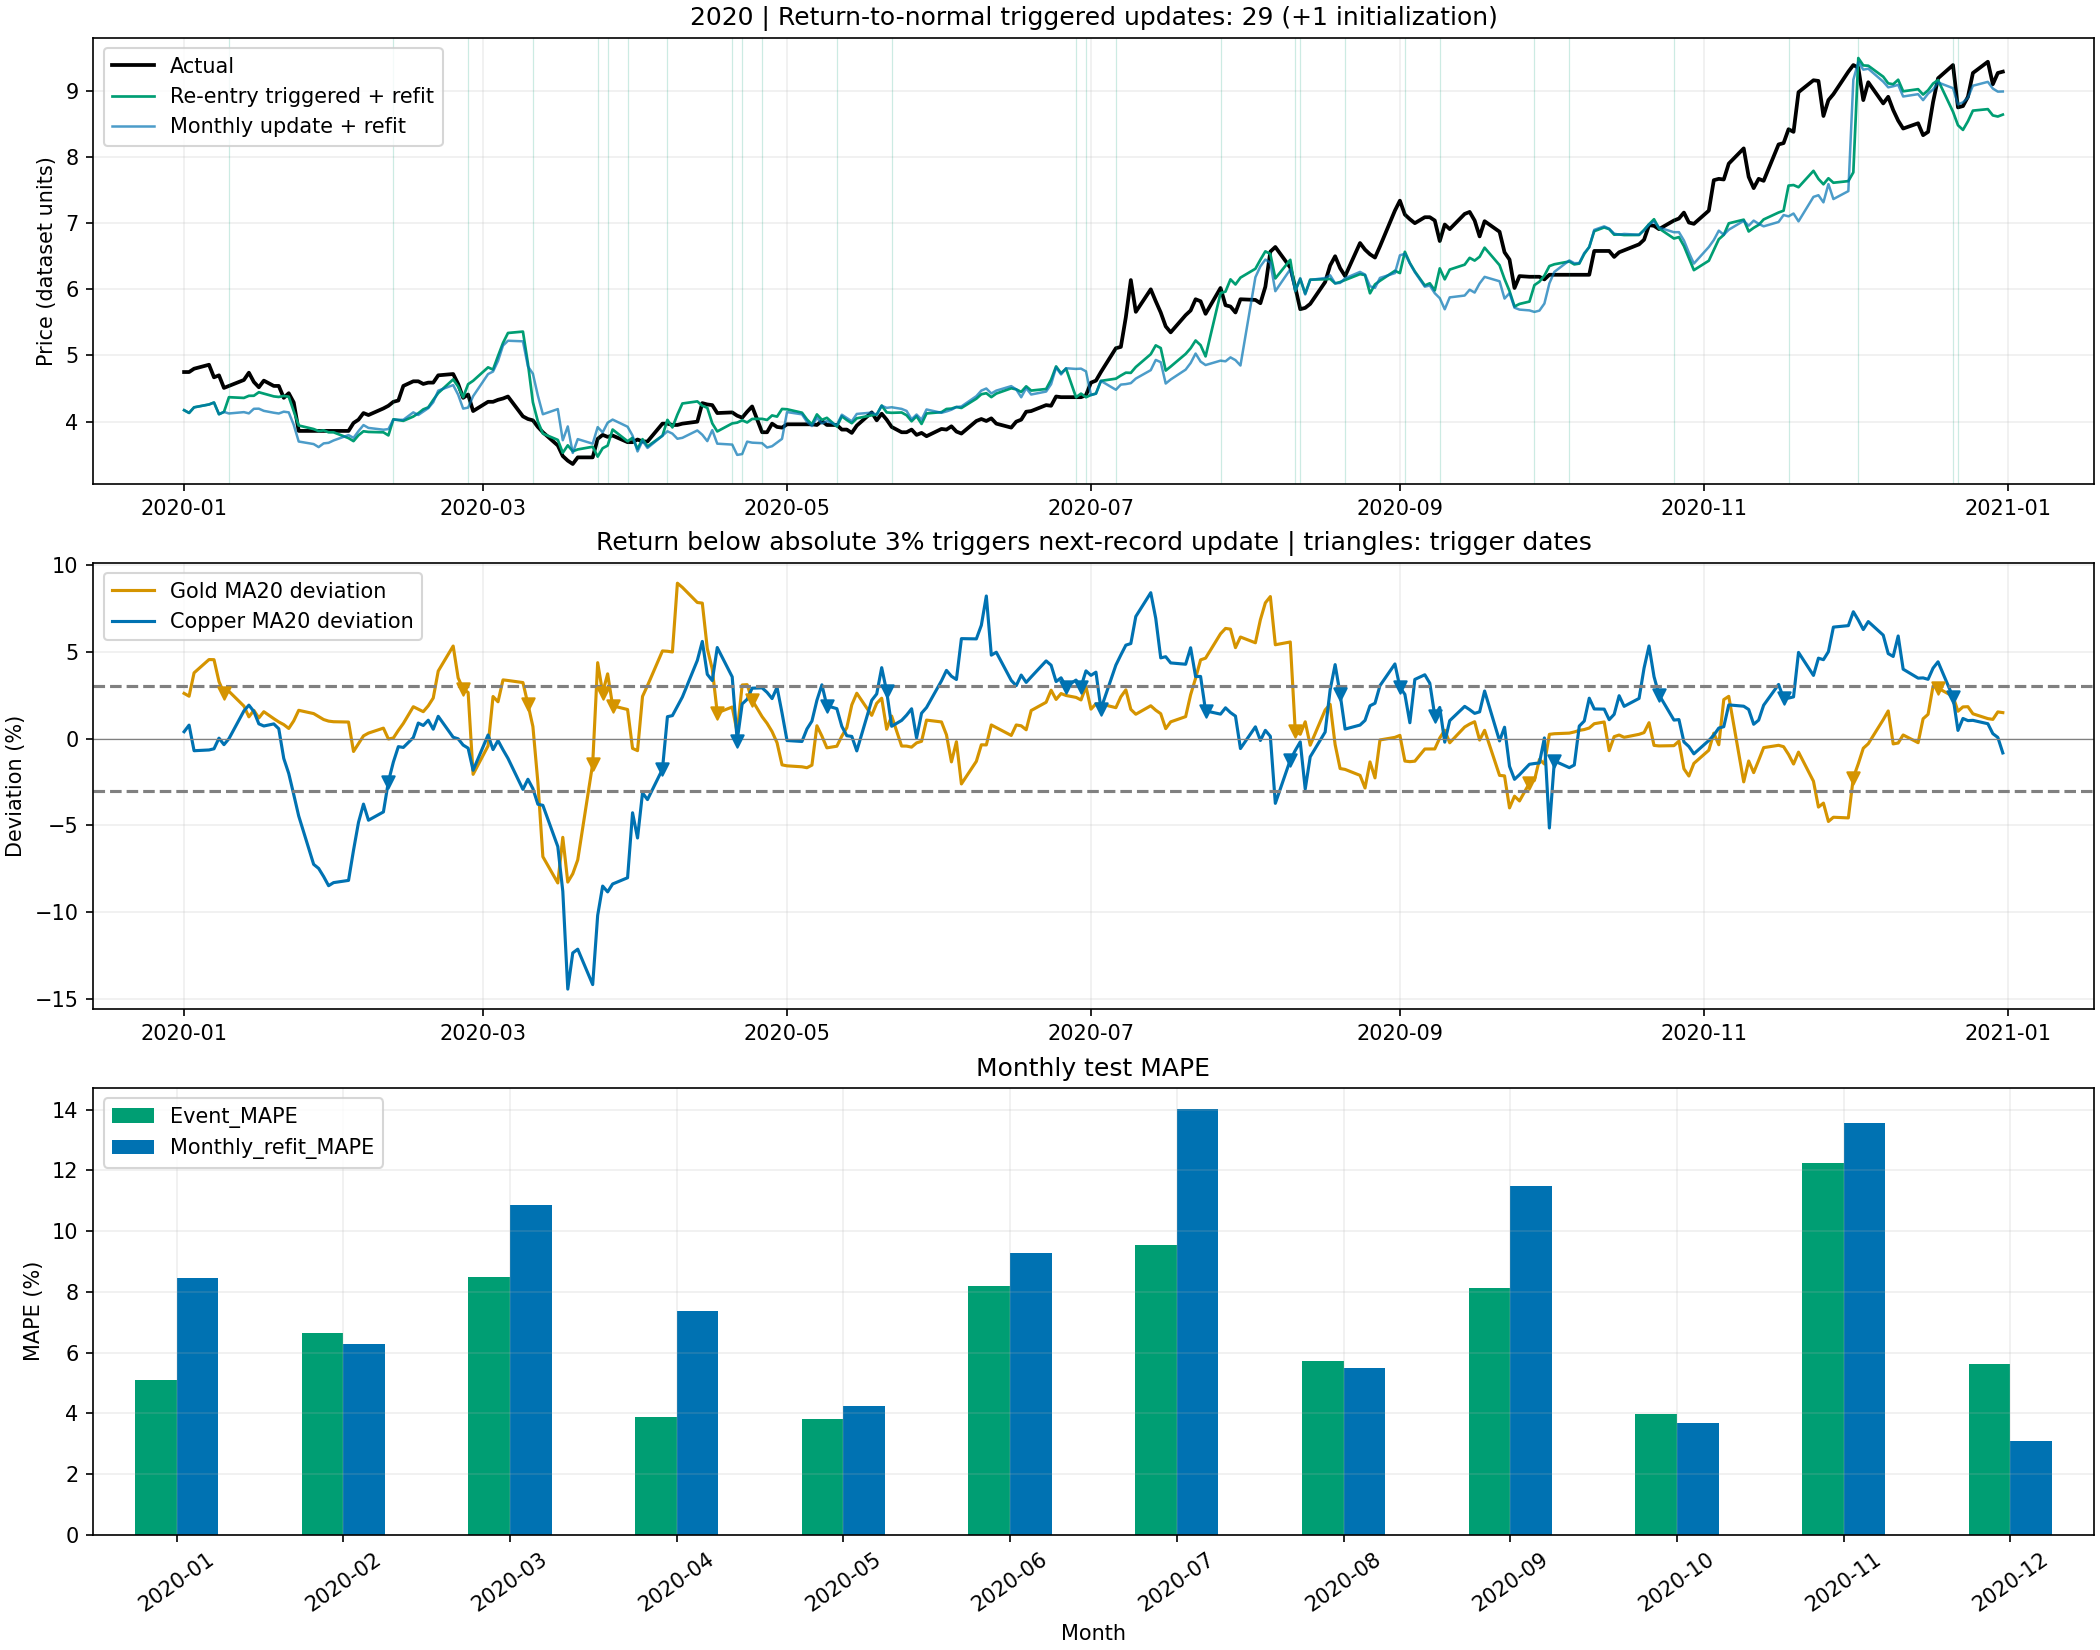

In [3]:
fig,axes=plt.subplots(3,1,figsize=(14,11),constrained_layout=True)
axes[0].plot(stitched.Date,stitched.Actual,color='black',lw=1.8,label='Actual')
axes[0].plot(stitched.Date,stitched.Predicted,color='#009E73',lw=1.3,label='Re-entry triggered + refit')
axes[0].plot(stitched.Date,stitched.Monthly_refit_prediction,color='#0072B2',lw=1.2,alpha=.7,label='Monthly update + refit')
for dt in schedule.loc[schedule.Kind=='Triggered','Effective_date']:axes[0].axvline(dt,color='#009E73',lw=.6,alpha=.2)
axes[0].set(title=f'2020 | Return-to-normal triggered updates: {counts["Triggered_updates"]} (+1 initialization)',ylabel='Price (dataset units)');axes[0].legend()
for metal,col,color in [('Gold','gold_vs_ma20','#D59400'),('Copper','copper_vs_ma20','#0072B2')]:
    axes[1].plot(whole,100*x.loc[whole,col],color=color,label=metal+' MA20 deviation')
axes[1].axhline(3,color='gray',ls='--');axes[1].axhline(-3,color='gray',ls='--');axes[1].axhline(0,color='gray',lw=.6)
for r in events.itertuples():
    if r.Gold_trigger:axes[1].scatter(r.Trigger_date,r.Gold_deviation_percent,color='#D59400',marker='v',s=35,zorder=5)
    if r.Copper_trigger:axes[1].scatter(r.Trigger_date,r.Copper_deviation_percent,color='#0072B2',marker='v',s=35,zorder=5)
axes[1].set(title='Return below absolute 3% triggers next-record update | triangles: trigger dates',ylabel='Deviation (%)');axes[1].legend()
monthly[['Event_MAPE','Monthly_refit_MAPE']].plot.bar(ax=axes[2],color=['#009E73','#0072B2'],rot=35)
axes[2].set(title='Monthly test MAPE',ylabel='MAPE (%)',xlabel='Month')
for ax in axes:ax.grid(alpha=.2)
fig.savefig(OUT/'reentry_comparison.png',dpi=150);plt.close(fig);display(Image(filename=str(OUT/'reentry_comparison.png')))


## 回归正常触发更新：结果与次数

2020年黄金回归正常12次，铜17次，同日合并后29个触发日，**实际更新29次**，无跨年待执行。另有年初初始化1次，因此全年依次使用30个已重训的堆叠模型。包括选择候选在内共训练300个候选堆叠模型＋30个最终重训模型，合计660个阶段训练任务，各100轮。选择候选不计为已应用模型的更新次数。

| 更新方案 | 全年逐记录MAPE | 月度等权MAPE | 全年MSE | 初始化以外更新次数 |
|---|---:|---:|---:|---:|
|偏离MA20达到3%后回归正常，次条记录更新|6.7342%|6.7733%|0.2595|29|
|每月验证选种子并纳入验证集重训|8.1499%|8.1528%|0.3381|11|

回归触发方案全年MAPE降低1.4158个百分点，12个月中8个月改善，2、8、10、12月变差；7月改善最大（−4.47个百分点），12月反而恶化2.53个百分点。

这说明该触发方案在本次2020年回测中表现更好，但更新更频繁，不能将全部改善归因于“回归正常”这个时机本身；需要同等更新频率的对照才能进一步分离频率和时机的影响。阈值3%、验证3个月、100轮按预定规则执行，没有按结果调整。

执行顺序已核对：触发当天仍用旧模型；每次更新训练与验证的最后记录严格早于生效日，合并重训最后日期等于触发日；生效日是触发后的下一条有效记录。例：2020-01-09触发→2020-01-10更新；2020-03-27触发→2020-03-30更新。原数据存在非A股交易日，实际触发与更新按原记录时间推进。

前一模型一直应用到下一生效日前，无空档；2020年271条记录无重复无遗漏。初始化至第一次更新前的预测已复现上一月度重训实验。

明细：`trigger_events.csv`记录金/铜原因与偏离幅度；`updates.csv`记录触发日、生效日、所选种子、训练验证边界及应用区间；`update_counts.json`记录更新次数；`validation_ranking.csv`记录每次10候选验证排名。输出在 `results/mlp_reentry_update_12`。


---

这个实验有一些问题,可能是因为我们的更新更加频繁,所以MAPE更好一点.

上一个实验是超过3%以后再回落更新,我们想要追上跳变,应该是超过的时候触发.回来的时候再触发.

---

# 金铜MA20±3%双向穿越触发：超出或回归，次条记录更新

保留上一节仅回归触发的实验，本节改为**金或铜任一种发生状态改变即触发**：`abs(P/MA20−1)<3%`为正常，`>=3%`为超出。从正常到超出、从超出回正常均触发。持续超出不每天重复触发，正负两侧都算；若从+4%直接到−4%，两条已观察记录都处于超出状态，不额外推断盘中穿越，不触发。同日金铜或不同方向信号合并为一次更新，不设冷却期。

其它条件与上一节完全一致：2020年、既定10候选种子、两阶段Stacking各100轮、前三日历月验证选种子，然后合并训练验证从头重训。触发当天继续使用旧模型，下一条有效记录开始时重训并应用；所有训练/验证标签截止触发日，不能使用生效日真实股价。初始化单独计数。

继续与原每月更新＋纳入验证数据重训方案对照；同时列出上一节仅回归触发的结果。仍为原Dataset同日输入的历史样本外回测，非月初/日初已知未来输入的严格提前预测。


In [1]:
from pathlib import Path
import os,json,hashlib,random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display,Image
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP12_CROSSING_OUT',str(ROOT/'results/mlp_crossing_update_12')));OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]
EXCLUDED_SEEDS=[0, 1, 7, 21, 42, 100, 123, 999, 2024, 2025]
EPOCHS=100;LR=0.01;VALIDATION_MONTHS=3
torch.set_num_threads(1);torch.use_deterministic_algorithms(True)
assert len(set(SEEDS))==10 and not set(SEEDS)&set(EXCLUDED_SEEDS)
dataset=ROOT/'src/pickle/Dataset.pkl';d=pd.read_pickle(dataset)
raw=d['X'].copy();target=d['Y'].copy();assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
raw=raw.loc[raw.index<'2021-01-01'];BASE=list(raw.columns);assert len(BASE)==7
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy();RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily';x[name]=raw[col]/raw[col].shift(1)-1;RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}';x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1;RETURNS.append(name)
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
x=x.loc[valid];y=y.loc[x.index];assert (y>0).all()
whole=x.index[x.index.year==2020];assert len(whole)==271
config=dict(seeds=SEEDS,excluded_prior_seeds=EXCLUDED_SEEDS,epochs_per_stage=EPOCHS,validation_months=VALIDATION_MONTHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions; base frozen',refit_after_selection=False,target='same-date original price',selection='minimum preceding-three-calendar-month MAPE; ties by candidate order',test_year=2020,dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
print('Frozen candidate seeds:',SEEDS)

THRESHOLD=.03
config.update(trigger='individual metal abs(MA20 deviation) crosses outward or inward at 3%; same-date events merged',threshold=THRESHOLD,effective='next available record',refit_after_selection=True,validation_window='three calendar months immediately before effective date',cooldown=None)
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
# 在完整历史计算状态，使2020年初状态继承自2019年；只执行2020年触发。
deviations=x[['gold_vs_ma20','copper_vs_ma20']]
outside=deviations.abs().ge(THRESHOLD)
previous=outside.shift(1)
valid_previous=previous.notna().all(axis=1)
entry=outside & previous.eq(False)
reentry=~outside & previous.eq(True)
crossing=(entry|reentry)&valid_previous.to_numpy()[:,None]
trigger_dates=reentry.index[(crossing.any(axis=1))&(reentry.index.year==2020)]
eventrows=[]
for day in trigger_dates:
    pos=x.index.get_loc(day);nextday=x.index[pos+1] if pos+1<len(x) else pd.NaT
    executable=pd.notna(nextday) and nextday.year==2020
    eventrows.append(dict(Trigger_date=day,Effective_date=nextday,Gold_trigger=bool(crossing.loc[day,'gold_vs_ma20']),Copper_trigger=bool(crossing.loc[day,'copper_vs_ma20']),Gold_direction=('outward' if entry.loc[day,'gold_vs_ma20'] else 'inward' if reentry.loc[day,'gold_vs_ma20'] else ''),Copper_direction=('outward' if entry.loc[day,'copper_vs_ma20'] else 'inward' if reentry.loc[day,'copper_vs_ma20'] else ''),Gold_deviation_percent=100*deviations.loc[day,'gold_vs_ma20'],Copper_deviation_percent=100*deviations.loc[day,'copper_vs_ma20'],Executable_in_2020=executable))
events=pd.DataFrame(eventrows)
events.to_csv(OUT/'trigger_events.csv',index=False)
schedule=[dict(Update_ID='initial',Kind='Initial',Trigger_date=pd.NaT,Effective_date=whole.min())]
for i,r in enumerate(events[events.Executable_in_2020].itertuples(index=False),1):
    schedule.append(dict(Update_ID=f'update_{i:02d}',Kind='Triggered',Trigger_date=r.Trigger_date,Effective_date=r.Effective_date))
schedule=pd.DataFrame(schedule).sort_values('Effective_date').reset_index(drop=True)
assert schedule.Effective_date.is_unique
print(f'触发日 {len(events)} 次；年内计划更新 {len(schedule)-1} 次；另有年初初始化1次。')
display(events)


,Trigger_date,Effective_date,Gold_trigger,Copper_trigger,Gold_direction,Copper_direction,Gold_deviation_percent,Copper_deviation_percent,Executable_in_2020
0,2020-01-03,2020-01-06,True,False,outward,,3.781956,-0.699238,True
1,2020-01-09,2020-01-10,True,False,inward,,2.612086,-0.349417,True
2,2020-01-23,2020-01-24,False,True,,outward,1.018186,-3.216644,True
3,2020-02-11,2020-02-12,False,True,,inward,-0.023948,-2.475336,True
4,2020-02-21,2020-02-24,True,False,outward,,3.884455,1.281281,True
5,2020-02-26,2020-02-27,True,False,inward,,2.854205,-0.374539,True
6,2020-03-05,2020-03-06,True,False,outward,,3.376295,-0.644862,True
7,2020-03-10,2020-03-11,True,False,inward,,1.984865,-2.341254,True
8,2020-03-12,2020-03-13,False,True,,outward,-2.524139,-3.778798,True
9,2020-03-13,2020-03-16,True,False,outward,,-6.797278,-3.842026,True


Frozen candidate seeds: [965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]
触发日 58 次；年内计划更新 58 次；另有年初初始化1次。


In [2]:
history=[]
def fit_stage(X,train_idx,seed,stage,month):
    random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
    sx=StandardScaler().fit(X.loc[train_idx]);sy=StandardScaler().fit(y.loc[train_idx].to_numpy().reshape(-1,1))
    xt=torch.tensor(sx.transform(X.loc[train_idx]),dtype=torch.float32);yt=torch.tensor(sy.transform(y.loc[train_idx].to_numpy().reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    for epoch in range(1,EPOCHS+1):
        model.train();opt.zero_grad();loss=((model(xt)-yt)**2).mean();assert torch.isfinite(loss)
        loss.backward();opt.step();model.eval()
        with torch.no_grad():z=model(xt).numpy()
        p=sy.inverse_transform(z).ravel();mse=float(np.mean((p-y.loc[train_idx].to_numpy())**2))
        history.append(dict(Update_ID=month,Seed=seed,Stage=stage,Epoch=epoch,Train_MSE=mse,Train_MSE_standardized=mse/float(sy.scale_[0]**2)))
    torch.save(dict(state_dict=model.state_dict(),features=list(X.columns),seed=seed,epochs=EPOCHS,train_start=str(train_idx.min()),train_end=str(train_idx.max()),sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist()),OUT/f'{month}_{stage}_seed{seed}.pt')
    return model,sx,sy

def predict(bundle,X):
    model,sx,sy=bundle;model.eval()
    with torch.no_grad():z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    p=sy.inverse_transform(z).ravel();assert np.isfinite(p).all();return pd.Series(p,index=X.index)

def score(pred,idx):
    err=pred.loc[idx].to_numpy()-y.loc[idx].to_numpy()
    return dict(N=len(idx),MAPE=float(100*np.mean(np.abs(err)/np.abs(y.loc[idx].to_numpy()))),MSE=float(np.mean(err**2)))

def stack_predict(base,stack,X):
    bp=predict(base,X[BASE]);meta=X[RETURNS].copy();meta.insert(0,'base_prediction',bp)
    return predict(stack,meta)

all_rankings=[];updates=[];frames=[];splitrows=[]
for j,row in enumerate(schedule.itertuples(index=False)):
    tag=row.Update_ID;effective=pd.Timestamp(row.Effective_date)
    stop=pd.Timestamp(schedule.iloc[j+1].Effective_date) if j+1<len(schedule) else pd.Timestamp('2021-01-01')
    val_start=effective-pd.DateOffset(months=VALIDATION_MONTHS)
    tr=x.index[x.index<val_start];va=x.index[(x.index>=val_start)&(x.index<effective)];refit_idx=x.index[x.index<effective]
    applied=x.index[(x.index>=effective)&(x.index<stop)]
    assert len(tr)>0 and len(va)>0 and len(applied)>0 and tr.max()<va.min() and va.max()<effective
    assert refit_idx.max()<effective and tr.union(va).equals(refit_idx)
    if row.Kind=='Triggered':
        assert refit_idx.max()==row.Trigger_date
        assert x.index[x.index.get_loc(row.Trigger_date)+1]==effective
    known=x.loc[refit_idx];candidates=[]
    for i,seed in enumerate(SEEDS):
        base=fit_stage(known[BASE],tr,seed,'CandidateBase',tag)
        bp=predict(base,known[BASE]);meta=known[RETURNS].copy();meta.insert(0,'base_prediction',bp)
        stack=fit_stage(meta,tr,seed,'CandidateStacking',tag)
        vp=predict(stack,meta)
        candidates.append(dict(Update_ID=tag,Seed=seed,Candidate_order=i,**score(vp,va)))
    ranking=pd.DataFrame(candidates).sort_values(['MAPE','Candidate_order']).reset_index(drop=True)
    ranking['Rank']=np.arange(1,11);chosen=int(ranking.iloc[0].Seed);ranking['Selected']=ranking.Seed.eq(chosen)
    all_rankings.append(ranking)
    decision=dict(Update_ID=tag,Kind=row.Kind,Trigger_date=None if pd.isna(row.Trigger_date) else str(row.Trigger_date.date()),Effective_date=str(effective.date()),Selected_seed=chosen,Validation_MAPE=float(ranking.iloc[0].MAPE),Candidate_train_end=str(tr.max().date()),Validation_start=str(va.min().date()),Validation_end=str(va.max().date()),Refit_train_end=str(refit_idx.max().date()),Refit_N=len(refit_idx))
    # 固定选择记录后，从头在训练+验证上重训；不读生效日真实股价。
    (OUT/f'{tag}_selection.json').write_text(json.dumps(decision,ensure_ascii=False,indent=2))
    final_base=fit_stage(known[BASE],refit_idx,chosen,'RefitBase',tag)
    bp=predict(final_base,known[BASE]);meta=known[RETURNS].copy();meta.insert(0,'base_prediction',bp)
    final_stack=fit_stage(meta,refit_idx,chosen,'RefitStacking',tag)
    pred=stack_predict(final_base,final_stack,x.loc[applied])
    updates.append(dict(**decision,Applied_end=str(applied.max().date()),Applied_N=len(applied),Applied_MAPE=score(pred,applied)['MAPE']))
    frames.append(pd.DataFrame(dict(Date=applied,Update_ID=tag,Seed=chosen,Actual=y.loc[applied].to_numpy(),Predicted=pred.to_numpy())))
    for split,idx in [('Candidate_train',tr),('Validation',va),('Refit_train',refit_idx),('Applied_test',applied)]:splitrows.append(dict(Update_ID=tag,Split=split,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())))
    print(f'{tag}: effective {effective.date()}, seed {chosen}, validation {ranking.iloc[0].MAPE:.3f}%, train through {refit_idx.max().date()}',flush=True)

stitched=pd.concat(frames,ignore_index=True).sort_values('Date')
assert stitched.Date.is_unique and pd.DatetimeIndex(stitched.Date).equals(whole)
assert len(history)==len(schedule)*(len(SEEDS)+1)*2*EPOCHS
stitched['APE']=100*np.abs(stitched.Predicted-stitched.Actual)/stitched.Actual.abs();stitched['Month']=stitched.Date.dt.strftime('%Y-%m')
monthly=stitched.groupby('Month').agg(N=('Date','size'),Event_MAPE=('APE','mean'))
PRIOR=OUT.parent/'mlp_monthly_refit_12'
if not (PRIOR/'stitched_comparison.csv').exists():PRIOR=ROOT/'results/mlp_monthly_refit_12'
old=pd.read_csv(PRIOR/'stitched_comparison.csv',parse_dates=['Date'])
check=stitched.merge(old[['Date','Actual','Refit_prediction']],on='Date',suffixes=('','_old'),validate='one_to_one')
assert len(check)==len(whole) and np.allclose(check.Actual,check.Actual_old)
stitched['Monthly_refit_prediction']=check.Refit_prediction.to_numpy()
stitched['Monthly_refit_APE']=100*np.abs(stitched.Monthly_refit_prediction-stitched.Actual)/stitched.Actual.abs()
monthly['Monthly_refit_MAPE']=stitched.groupby('Month').Monthly_refit_APE.mean()
monthly['Event_minus_monthly_pp']=monthly.Event_MAPE-monthly.Monthly_refit_MAPE
# 初始化与原1月合并验证重训使用同一规则，首个更新前应复现其预测。
first=stitched.Update_ID=='initial';assert np.allclose(stitched.loc[first,'Predicted'],stitched.loc[first,'Monthly_refit_prediction'],atol=1e-5,rtol=0)
counts=dict(Gold_crossings=int(events.Gold_trigger.sum()),Copper_crossings=int(events.Copper_trigger.sum()),Gold_outward=int(events.Gold_direction.eq('outward').sum()),Gold_inward=int(events.Gold_direction.eq('inward').sum()),Copper_outward=int(events.Copper_direction.eq('outward').sum()),Copper_inward=int(events.Copper_direction.eq('inward').sum()),Merged_trigger_days=len(events),Triggered_updates=int((schedule.Kind=='Triggered').sum()),Pending_after_2020=int((~events.Executable_in_2020).sum()),Initializations=1,Total_deployed_models=len(schedule),Candidate_models_trained=len(schedule)*len(SEEDS),Refit_models_trained=len(schedule),Total_stage_trainings=len(schedule)*(len(SEEDS)+1)*2)
summary=pd.DataFrame([dict(Method='Outward-or-inward crossing updates',Annual_daily_MAPE=stitched.APE.mean(),Monthly_equal_MAPE=monthly.Event_MAPE.mean(),Annual_MSE=np.mean((stitched.Predicted-stitched.Actual)**2),Updates_excluding_initial=counts['Triggered_updates']),dict(Method='Monthly selected seed + refit',Annual_daily_MAPE=stitched.Monthly_refit_APE.mean(),Monthly_equal_MAPE=monthly.Monthly_refit_MAPE.mean(),Annual_MSE=np.mean((stitched.Monthly_refit_prediction-stitched.Actual)**2),Updates_excluding_initial=11)])
assert np.isclose(stitched.APE.mean(),np.average(monthly.Event_MAPE,weights=monthly.N))
for name,frame in [('stitched_predictions',stitched),('updates',pd.DataFrame(updates)),('validation_ranking',pd.concat(all_rankings,ignore_index=True)),('splits',pd.DataFrame(splitrows)),('summary',summary),('training_history',pd.DataFrame(history))]:frame.to_csv(OUT/f'{name}.csv',index=False)
monthly.to_csv(OUT/'monthly_comparison.csv');(OUT/'update_counts.json').write_text(json.dumps(counts,indent=2))
print('更新次数（初始化单列）：',counts);display(pd.DataFrame(updates));display(monthly.round(4));display(summary.round(4))

# 旧回归触发方案只读复用，不重新训练。
REENTRY=OUT.parent/'mlp_reentry_update_12'
if not (REENTRY/'stitched_predictions.csv').exists():REENTRY=ROOT/'results/mlp_reentry_update_12'
prior_event=pd.read_csv(REENTRY/'stitched_predictions.csv',parse_dates=['Date'])
assert pd.DatetimeIndex(prior_event.Date).equals(whole) and np.allclose(prior_event.Actual,stitched.Actual)
stitched['Reentry_only_prediction']=prior_event.Predicted.to_numpy()
stitched['Reentry_only_APE']=100*np.abs(stitched.Reentry_only_prediction-stitched.Actual)/stitched.Actual.abs()
monthly['Reentry_only_MAPE']=stitched.groupby('Month').Reentry_only_APE.mean()
monthly['Both_minus_reentry_pp']=monthly.Event_MAPE-monthly.Reentry_only_MAPE
oldcounts=json.loads((REENTRY/'update_counts.json').read_text())
summary=pd.concat([summary,pd.DataFrame([dict(Method='Inward-only updates',Annual_daily_MAPE=stitched.Reentry_only_APE.mean(),Monthly_equal_MAPE=monthly.Reentry_only_MAPE.mean(),Annual_MSE=np.mean((stitched.Reentry_only_prediction-stitched.Actual)**2),Updates_excluding_initial=oldcounts['Triggered_updates'])])],ignore_index=True)
stitched.to_csv(OUT/'stitched_predictions.csv',index=False);monthly.to_csv(OUT/'monthly_comparison.csv');summary.to_csv(OUT/'summary.csv',index=False)
# 检查两个方向确实涵盖旧回归触发日，且每个事件均有可验证的前后状态改变。
old_events=pd.read_csv(REENTRY/'trigger_events.csv',parse_dates=['Trigger_date'])
assert set(old_events.Trigger_date)<=set(events.Trigger_date)
for r in events.itertuples():
    for metal,flag,direction in [('gold',r.Gold_trigger,r.Gold_direction),('copper',r.Copper_trigger,r.Copper_direction)]:
        if flag:
            col=metal+'_vs_ma20';i=x.index.get_loc(r.Trigger_date)
            before=bool(outside.iloc[i-1][col]);after=bool(outside.iloc[i][col])
            assert before!=after and direction==('outward' if after else 'inward')
print('与仅回归、每月重训的完整对照：');display(summary.round(4))


,Update_ID,Kind,Trigger_date,Effective_date,Selected_seed,Validation_MAPE,Candidate_train_end,Validation_start,Validation_end,Refit_train_end,Refit_N,Applied_end,Applied_N,Applied_MAPE
0,initial,Initial,None,2020-01-01,785634,6.025555,2019-09-30,2019-10-01,2019-12-31,2019-12-31,2035,2020-01-03,3,12.436852
1,update_01,Triggered,2020-01-03,2020-01-06,785634,6.230528,2019-10-04,2019-10-07,2020-01-03,2020-01-03,2038,2020-01-09,4,9.450765
2,update_02,Triggered,2020-01-09,2020-01-10,785634,6.758838,2019-10-09,2019-10-10,2020-01-09,2020-01-09,2042,2020-01-23,11,3.592611
3,update_03,Triggered,2020-01-23,2020-01-24,965409,9.180832,2019-10-23,2019-10-24,2020-01-23,2020-01-23,2053,2020-02-11,13,2.438626
4,update_04,Triggered,2020-02-11,2020-02-12,785634,10.214028,2019-11-11,2019-11-12,2020-02-11,2020-02-11,2066,2020-02-21,9,8.288225
5,update_05,Triggered,2020-02-21,2020-02-24,785634,12.407999,2019-11-22,2019-11-25,2020-02-21,2020-02-21,2075,2020-02-26,3,4.430501
6,update_06,Triggered,2020-02-26,2020-02-27,785634,12.301034,2019-11-26,2019-11-27,2020-02-26,2020-02-26,2078,2020-03-05,6,12.095116
7,update_07,Triggered,2020-03-05,2020-03-06,785634,12.193347,2019-12-05,2019-12-06,2020-03-05,2020-03-05,2084,2020-03-10,3,16.583289
8,update_08,Triggered,2020-03-10,2020-03-11,785634,11.998093,2019-12-10,2019-12-11,2020-03-10,2020-03-10,2087,2020-03-12,2,4.442617
9,update_09,Triggered,2020-03-12,2020-03-13,785634,11.804696,2019-12-12,2019-12-13,2020-03-12,2020-03-12,2089,2020-03-13,1,0.710396


,N,Event_MAPE,Monthly_refit_MAPE,Event_minus_monthly_pp
Month,,,,
2020-01,24,5.3376,8.4636,-3.1260
2020-02,21,5.7456,6.2803,-0.5347
2020-03,22,10.1836,10.8491,-0.6654
2020-04,23,3.7247,7.3819,-3.6572
2020-05,23,3.7326,4.2413,-0.5088
2020-06,23,7.7483,9.2889,-1.5406
2020-07,23,7.5428,14.0170,-6.4742
2020-08,21,5.5105,5.4751,0.0355
2020-09,24,7.0664,11.4930,-4.4265


,Method,Annual_daily_MAPE,Monthly_equal_MAPE,Annual_MSE,Updates_excluding_initial
0,Outward-or-inward crossing updates,6.3819,6.4186,0.2113,58
1,Monthly selected seed + refit,8.1499,8.1528,0.3381,11


,Method,Annual_daily_MAPE,Monthly_equal_MAPE,Annual_MSE,Updates_excluding_initial
0,Outward-or-inward crossing updates,6.3819,6.4186,0.2113,58
1,Monthly selected seed + refit,8.1499,8.1528,0.3381,11
2,Inward-only updates,6.7342,6.7733,0.2595,29


initial: effective 2020-01-01, seed 785634, validation 6.026%, train through 2019-12-31
update_01: effective 2020-01-06, seed 785634, validation 6.231%, train through 2020-01-03
update_02: effective 2020-01-10, seed 785634, validation 6.759%, train through 2020-01-09
update_03: effective 2020-01-24, seed 965409, validation 9.181%, train through 2020-01-23
update_04: effective 2020-02-12, seed 785634, validation 10.214%, train through 2020-02-11
update_05: effective 2020-02-24, seed 785634, validation 12.408%, train through 2020-02-21
update_06: effective 2020-02-27, seed 785634, validation 12.301%, train through 2020-02-26
update_07: effective 2020-03-06, seed 785634, validation 12.193%, train through 2020-03-05
update_08: effective 2020-03-11, seed 785634, validation 11.998%, train through 2020-03-10
update_09: effective 2020-03-13, seed 785634, validation 11.805%, train through 2020-03-12
update_10: effective 2020-03-16, seed 965409, validation 11.549%, train through 2020-03-13
updat

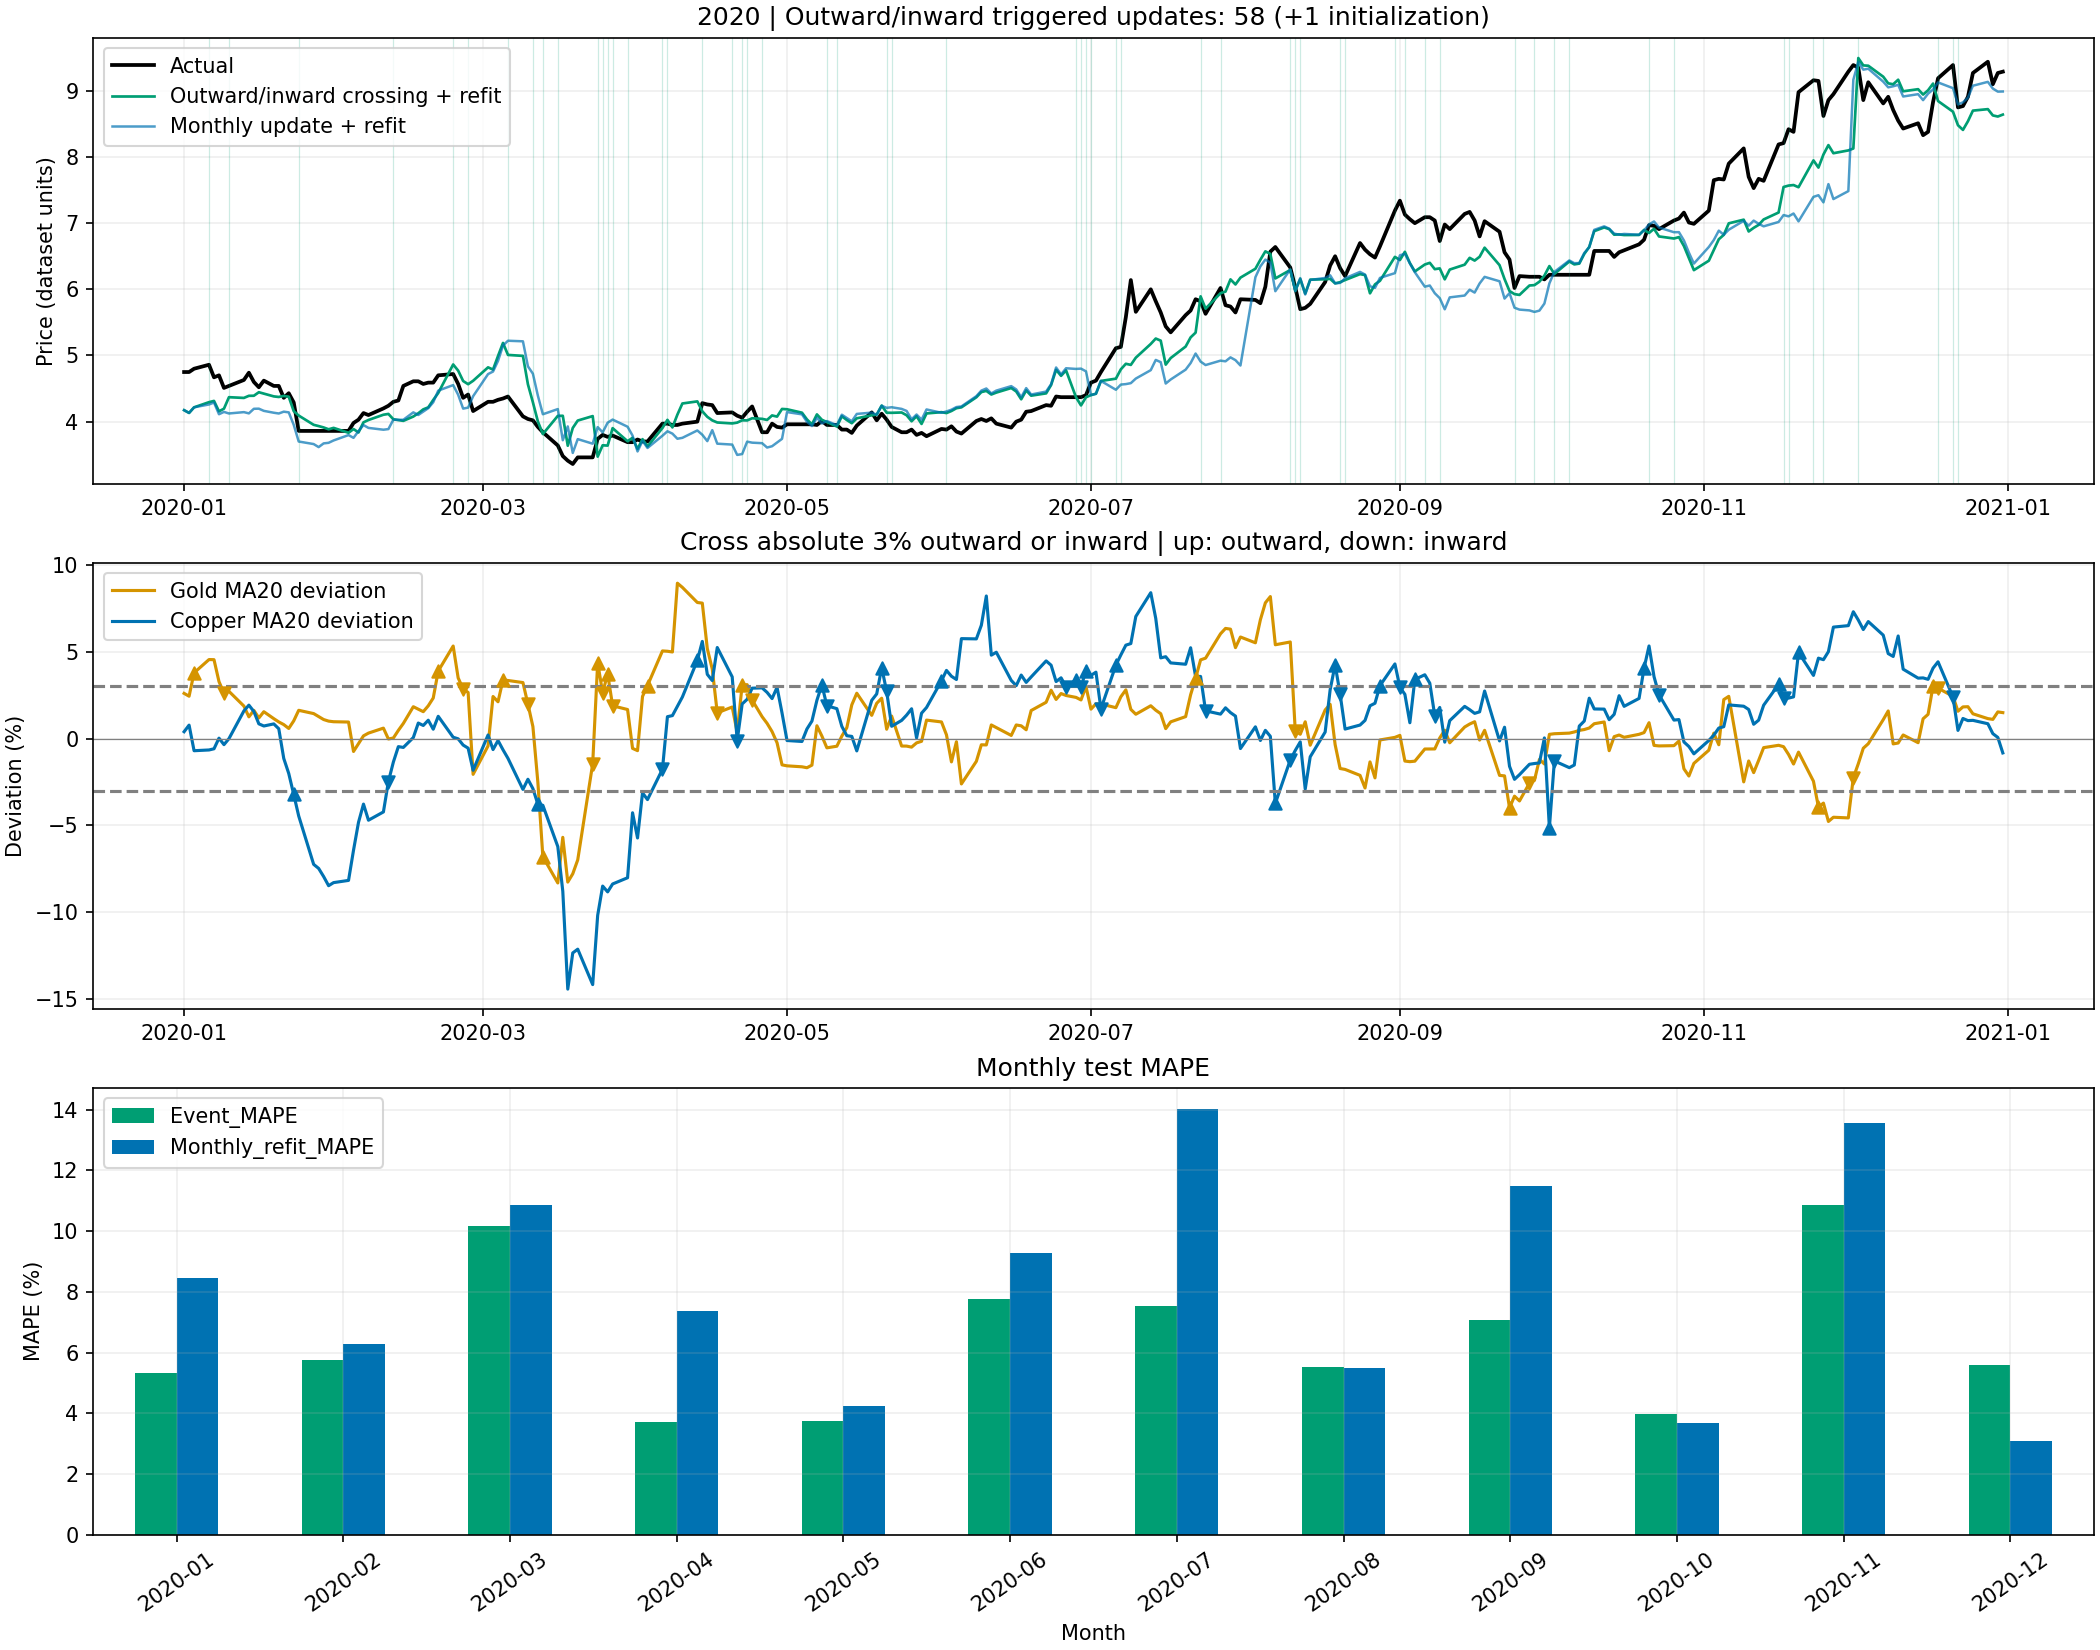

In [3]:
fig,axes=plt.subplots(3,1,figsize=(14,11),constrained_layout=True)
axes[0].plot(stitched.Date,stitched.Actual,color='black',lw=1.8,label='Actual')
axes[0].plot(stitched.Date,stitched.Predicted,color='#009E73',lw=1.3,label='Outward/inward crossing + refit')
axes[0].plot(stitched.Date,stitched.Monthly_refit_prediction,color='#0072B2',lw=1.2,alpha=.7,label='Monthly update + refit')
for dt in schedule.loc[schedule.Kind=='Triggered','Effective_date']:axes[0].axvline(dt,color='#009E73',lw=.6,alpha=.2)
axes[0].set(title=f'2020 | Outward/inward triggered updates: {counts["Triggered_updates"]} (+1 initialization)',ylabel='Price (dataset units)');axes[0].legend()
for metal,col,color in [('Gold','gold_vs_ma20','#D59400'),('Copper','copper_vs_ma20','#0072B2')]:
    axes[1].plot(whole,100*x.loc[whole,col],color=color,label=metal+' MA20 deviation')
axes[1].axhline(3,color='gray',ls='--');axes[1].axhline(-3,color='gray',ls='--');axes[1].axhline(0,color='gray',lw=.6)
for r in events.itertuples():
    if r.Gold_trigger:axes[1].scatter(r.Trigger_date,r.Gold_deviation_percent,color='#D59400',marker='^' if r.Gold_direction=='outward' else 'v',s=35,zorder=5)
    if r.Copper_trigger:axes[1].scatter(r.Trigger_date,r.Copper_deviation_percent,color='#0072B2',marker='^' if r.Copper_direction=='outward' else 'v',s=35,zorder=5)
axes[1].set(title='Cross absolute 3% outward or inward | up: outward, down: inward',ylabel='Deviation (%)');axes[1].legend()
monthly[['Event_MAPE','Monthly_refit_MAPE']].plot.bar(ax=axes[2],color=['#009E73','#0072B2'],rot=35)
axes[2].set(title='Monthly test MAPE',ylabel='MAPE (%)',xlabel='Month')
for ax in axes:ax.grid(alpha=.2)
fig.savefig(OUT/'crossing_comparison.png',dpi=150);plt.close(fig);display(Image(filename=str(OUT/'crossing_comparison.png')))


## 双向穿越实验结果

| 方案 | 全年逐记录MAPE | 月度等权MAPE | 全年MSE | 更新次数（不含初始化） |
|---|---:|---:|---:|---:|
|每月选种子＋纳入验证重训|8.1499%|8.1528%|0.3381|11|
|仅回归正常触发|6.7342%|6.7733%|0.2595|29|
|超出或回归均触发|6.3819%|6.4186%|0.2113|58|

双向方案相对每月更新降低1.7681个百分点（约相对降低21.7%），12个月中9个月改善，8、10、12月变差。其中7月改善最大（−6.47个百分点），12月恶化2.51个百分点。

相对仅回归触发，双向方案全年改善0.3523个百分点，但更新次数从29增至58。更新时机和频率同时改变，不能单独把改善解释为“超出时更新”必然更优，2020年结果仍需跨时期检验。

| 月份 | 双向穿越MAPE | 每月更新MAPE | 双向−每月（百分点） |
|---|---:|---:|---:|
|2020-01|5.338%|8.464%|-3.126|
|2020-02|5.746%|6.280%|-0.535|
|2020-03|10.184%|10.849%|-0.665|
|2020-04|3.725%|7.382%|-3.657|
|2020-05|3.733%|4.241%|-0.509|
|2020-06|7.748%|9.289%|-1.541|
|2020-07|7.543%|14.017%|-6.474|
|2020-08|5.511%|5.475%|+0.035|
|2020-09|7.066%|11.493%|-4.427|
|2020-10|3.967%|3.691%|+0.276|
|2020-11|10.874%|13.574%|-2.700|
|2020-12|5.590%|3.079%|+2.511|

触发计数：黄金向外12次、回归12次，共24次；铜向外17次、回归17次，共34次。本年没有同日合并，实际触发与更新均为58次；加年初初始化共59个最终应用的模型。10候选选择与最终重训合计590个候选堆叠模型＋59个最终重训模型，两阶段共1298个100轮训练任务。更新次数只统计实际应用模型的替换，不把候选训练计入。

逐事件核对前后超标状态确实变化，旧版全部29个回归触发日期均包含在新版中；每次触发后下一条记录才生效，训练验证标签全部早于生效日。全年271条预测无遗漏、无重复，初始化至首次更新前与每月重训对照一致。

新规则能更早响应由正常转为超标的情况，但模型替换本身仍可能导致预测水平跳变；它不是曲线平滑机制。若金铜一直保持超标而无状态穿越，本规则仍不会持续更新。

输出在 `results/mlp_crossing_update_12`，包括完整代码、逐事件方向和日期、实际更新次数、每次验证排名、选中种子、模型权重、全年预测与逐月对照。前面实验保持不变。


## 新数据加入了，但在训练中的占比太小。
11月更新时，训练集约有2270多条记录。最近20条只占约 0.88%。目前所有样本等权，因此即使每天重新训练，新增一天也只增加很少的信息权重。

普通的MSE对误差一视同仁,加入了新误差可能会为了拟合旧的数据,选择一个折中的优化结果.

如果我们使用近期样本加权,通过控制不同的半衰期,给予近期的差额更高的权重,是否能改善模型?